# Two-Dimensional Example 3 — Multi-Scale Hierarchical Function

## Motivation: Challenging DGP with a Non-Stationary, Multi-Scale Target

**True function:**
$$f^*(x_1, x_2) = \cos(0.5\,x_1)\sin(0.5\,x_2) \cdot \tanh\!\bigl(3\sin(4x_1) + 3\cos(4x_2)\bigr)$$

This function has **two distinct length scales**:
- **Global envelope** $\cos(0.5x_1)\sin(0.5x_2)$: slow-varying, period $\approx 12$ — captured by wide kernels
- **Local modulation** $\tanh(3\sin(4x_1)+3\cos(4x_2))$: rapid oscillation, period $\approx 1.6$ — captured by tight kernels

**Why this challenges DGP:** A single-layer GP with one RBF kernel must choose **one** length-scale.
It either over-smooths the fast oscillations or over-fits the slow envelope.
MLKM's two-layer architecture naturally decomposes the function — Layer 1 (wider $\gamma_1$) captures
the global trend; Layer 2 (tighter $\gamma_2$) resolves the rapid modulation.

**Sections:**
- Section 1: Baseline Comparison (σ=0.01 and σ=0.1)
- Section 2: Sample Size Experiment (both σ values)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, random, sys, os, gc, resource, threading
import tracemalloc, ctypes
from tqdm import tqdm
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import multiprocessing as mp
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.9.1
CUDA available: False


In [39]:
# ── Global hyperparameters ──────────────────────────────────────────────────
SEED      = 42
H1, H2    = 32, 8        # DNN / ResNet hidden widths
BATCH     = 64
MAX_EP    = 2000
ESW       = 50           # early-stopping window (epochs)
LR, MOM, WD = 0.01, 0.9, 1e-4

D_DEF     = 32           # default RFF dimension
GAMMA_DEF = 1.0          # default RFF bandwidth


N_SIZES   = [200, 500, 1000, 2000, 5000]
D_VALUES  = list(range(32, 513, 32))   # [32, 64, ..., 512]
GAMMAS    = [0.1, 0.5, 1.0, 2.0, 5.0]

# ── Results directory ────────────────────────────────────────────────────────
RESULTS_DIR = 'ex3_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print(f'Results folder: {RESULTS_DIR}/')

Device: cpu
Results folder: ex3_results/


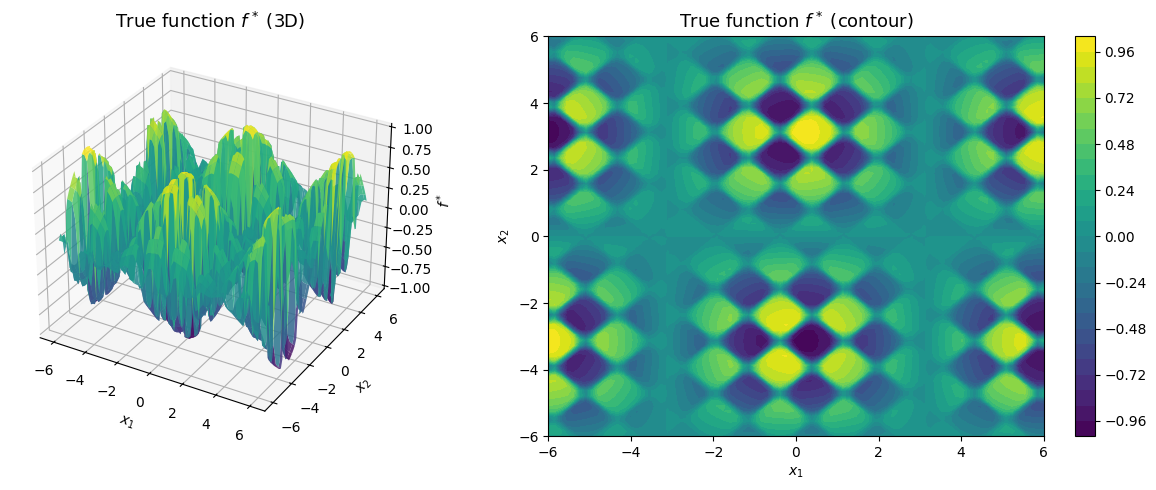

f* range: [-0.998, 0.998]


In [40]:
# ── True function: multi-scale hierarchical ─────────────────────────────────
def f_star(X):
    """
    f*(x1,x2) = cos(0.5*x1)*sin(0.5*x2) * tanh(3*sin(4*x1) + 3*cos(4*x2))

    Global envelope  : cos(0.5*x1)*sin(0.5*x2)  — period ~12, slow-varying
    Local modulation : tanh(3*sin(4*x1)+3*cos(4*x2)) — period ~1.6, fast oscillation

    The product creates non-stationary amplitude variation that a single-scale
    GP kernel cannot efficiently represent.
    """
    x1, x2 = X[:, 0], X[:, 1]
    envelope   = np.cos(0.5 * x1) * np.sin(0.5 * x2)
    modulation = np.tanh(3 * np.sin(4 * x1) + 3 * np.cos(4 * x2))
    return (envelope * modulation).astype('float32')

# ── Data generation ─────────────────────────────────────────────────────────
def generate_data(n, n_cal=1000, n_test=2000, sigma=0.01, seed=0):
    rng   = np.random.RandomState(seed)
    X_tr  = rng.uniform(-2, 2, (n, 2)).astype('float32')
    y_tr  = f_star(X_tr)  + (sigma * rng.randn(n)).astype('float32')
    X_cal = rng.uniform(-2, 2, (n_cal, 2)).astype('float32')
    y_cal = f_star(X_cal) + (sigma * rng.randn(n_cal)).astype('float32')
    X_te  = rng.uniform(-2, 2, (n_test, 2)).astype('float32')
    y_te  = f_star(X_te)  + (sigma * rng.randn(n_test)).astype('float32')
    return X_tr, y_tr, X_cal, y_cal, X_te, y_te

# ── Visualise true function ──────────────────────────────────────────────────
x_g = np.linspace(-6, 6, 80)
xx, yy = np.meshgrid(x_g, x_g)
Z = f_star(np.column_stack([xx.ravel(), yy.ravel()])).reshape(80, 80)
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.85)
ax1.set_title('True function $f^*$ (3D)', fontsize=13)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_zlabel('$f^*$')
ax2 = fig.add_subplot(1, 2, 2)
im = ax2.contourf(xx, yy, Z, levels=30, cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('True function $f^*$ (contour)', fontsize=13)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ex3_true_function.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'f* range: [{Z.min():.3f}, {Z.max():.3f}]')

In [41]:
GAMMA_DEF = 1.0          # default RFF bandwidth

set_seed(SEED)
n_base = 5000
X_tr1, y_tr1, X_cal1, y_cal1, X_te1, y_te1 = generate_data(
    n_base, n_cal=1000, n_test=2000, sigma=0.01, seed=0)

for name, X, y in [('Train', X_tr1, y_tr1), ('Cal', X_cal1, y_cal1), ('Test', X_te1, y_te1)]:
    print(f'{name}: X={X.shape}  y_range=[{y.min():.3f}, {y.max():.3f}]')

dists = np.sum((X_tr1[None, :, :] - X_tr1[:, None, :])**2, axis=-1)
dists_flat = dists[np.triu_indices(len(X_tr1), k=1)]

median_sqdist = float(np.median(dists_flat))
sigma_median  = float(np.sqrt(median_sqdist))   # median Euclidean distance

gamma_median = float(1.0 / sigma_median)

GAMMA_DEF = gamma_median
print(f"median_sqdist  = {median_sqdist:.6f}")
print(f"sigma_median   = {sigma_median:.6f}")
print(f"gamma_median   = {gamma_median:.6f}  (correct, 1/sqrt(median_sqdist))")
print(f"old formula    = {1/(2*median_sqdist):.6f}  (wrong, was 1/(2*median_sqdist))")



Train: X=(5000, 2)  y_range=[-0.826, 0.831]
Cal: X=(1000, 2)  y_range=[-0.813, 0.821]
Test: X=(2000, 2)  y_range=[-0.835, 0.819]
median_sqdist  = 4.228266
sigma_median   = 2.056275
gamma_median   = 0.486316  (correct, 1/sqrt(median_sqdist))
old formula    = 0.118252  (wrong, was 1/(2*median_sqdist))


In [42]:
class DS(Dataset):
    def __init__(self, x, y):
        self.x = torch.from_numpy(x)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

def mkl(x, y, bs=BATCH):
    return DataLoader(DS(x, y), batch_size=bs, shuffle=True)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.uniform_(m.weight, -0.1, 0.1)
        if m.bias is not None: nn.init.constant_(m.bias, 0.01)

class RFFModule:
    def __init__(self, d, D, gamma=1.0):
        self.W = torch.randn(D, d) * gamma
        self.b = torch.rand(D) * 2 * torch.pi
        self.D = D
    def transform(self, x):
        W = self.W.to(x.device)
        b = self.b.to(x.device)
        ones = torch.ones(len(x), device=x.device)
        return (torch.sqrt(torch.tensor(2.0 / self.D, device=x.device)) *
                torch.cos(W @ x.T + b.reshape(-1, 1) * ones.reshape(1, -1))).T

In [43]:
# ── Per-layer gamma helpers ───────────────────────────────────────────────────
def _compute_layer_gamma(X_np, n_sub=2000, seed=42):
    """
    Median-distance heuristic for the RFF kernel exp(-gamma^2/2 * ||x-y||^2).
    Returns gamma = 1 / sqrt(median_sq_dist).
    """
    if len(X_np) > n_sub:
        idx = np.random.RandomState(seed).choice(len(X_np), n_sub, replace=False)
        X_sub = X_np[idx]
    else:
        X_sub = X_np
    diffs  = X_sub[None, :, :] - X_sub[:, None, :]
    sqdist = (diffs ** 2).sum(axis=-1)
    triu   = sqdist[np.triu_indices(len(X_sub), k=1)]
    med    = float(np.median(triu))
    return 1.0 / np.sqrt(med) if med > 0 else 1.0

def _compute_per_layer_gammas(X_np, D=D_DEF, H=H2, seed=SEED):
    """
    Per-layer gammas for KernelNet / ResKernelNet.
    Layer-1 gamma from raw input; Layer-2 gamma from layer-1 activations.
    Temp objects deleted — does NOT inflate memory measurement.
    """
    g1 = _compute_layer_gamma(X_np)
    with torch.no_grad():
        torch.manual_seed(seed)
        _rff1 = RFFModule(X_np.shape[1], D, gamma=g1)
        _fc1  = nn.Linear(D, H)
        _h1   = _fc1(_rff1.transform(torch.from_numpy(X_np).float())).numpy()
    g2 = _compute_layer_gamma(_h1)
    del _rff1, _fc1, _h1
    return g1, g2


In [44]:
class DNN(nn.Module):
    def __init__(self, H1=H1, H2=H2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, H1), nn.ReLU(),
            nn.Linear(H1, H2), nn.ReLU(),
            nn.Linear(H2, 1))
    def forward(self, x): return self.net(x)

class ResBlock(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.fc1 = nn.Linear(in_f, out_f)
        self.fc2 = nn.Linear(in_f, out_f)
    def forward(self, x): return F.relu(F.relu(self.fc1(x)) + self.fc2(x))

class ResNet(nn.Module):
    def __init__(self, H1=H1, H2=H2):
        super().__init__()
        self.blocks = nn.Sequential(ResBlock(2, H1), ResBlock(H1, H2))
        self.out = nn.Linear(H2, 1)
    def forward(self, x): return self.out(self.blocks(x))

class KernelNet(nn.Module):
    def __init__(self, D=D_DEF, gamma=GAMMA_DEF, H=H2, gammas=None):
        super().__init__()
        g1, g2 = gammas if gammas is not None else (gamma, gamma)
        self.rff1 = RFFModule(2, D, gamma=g1)   # g1 from input X
        self.rff2 = RFFModule(H, H, gamma=g2)   # g2 from layer-1 output
        self.fc1  = nn.Linear(D, H)
        self.fc2  = nn.Linear(H, 1)
    def forward(self, x):
        x = self.fc1(self.rff1.transform(x))
        return self.fc2(self.rff2.transform(x))

class ResKernelNet(nn.Module):
    def __init__(self, D1=D_DEF, gamma=GAMMA_DEF, H=H2, gammas=None):
        super().__init__()
        g1, g2 = gammas if gammas is not None else (gamma, gamma)
        self.rff1 = RFFModule(2, D1, gamma=g1)   # g1 from input X
        self.fc1  = nn.Linear(D1, H)
        self.rff2 = RFFModule(H, H, gamma=g2)    # g2 from layer-1 output
        self.fc2  = nn.Linear(H, H)
        self.out  = nn.Linear(H, 1)
    def forward(self, x):
        h = self.fc1(self.rff1.transform(x))
        return self.out(h + self.fc2(self.rff2.transform(h)))

In [45]:
# ── Extra imports ─────────────────────────────────────────────────────────────
import gpytorch, psutil
from gpytorch.models import ExactGP
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.distributions import MultivariateNormal
from gpytorch import variational

def _release_memory():
    gc.collect(); gc.collect(); gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception: pass

def measure_memory_cpu(func, *args, **kwargs):
    """Warm-up + measured run. Returns (result, delta_MB, peak_MB)."""
    _release_memory()
    try: func(*args, **kwargs)
    except Exception: pass
    _release_memory()

    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss
    _hwm_factor = 1 if sys.platform == 'darwin' else 1024
    hwm_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    peak_rss = [mem_before]; stop_evt = threading.Event()
    def _monitor():
        while not stop_evt.is_set():
            try:
                cur = proc.memory_info().rss
                if cur > peak_rss[0]: peak_rss[0] = cur
            except Exception: pass
            stop_evt.wait(0.01)
    mon_thread = threading.Thread(target=_monitor, daemon=True)
    try: tracemalloc.stop()
    except Exception: pass
    tracemalloc.start(); mon_thread.start()
    result = func(*args, **kwargs)
    mem_after = proc.memory_info().rss
    hwm_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    stop_evt.set(); mon_thread.join()
    _, peak_bytes_tm = tracemalloc.get_traced_memory(); tracemalloc.stop()
    if mem_after > peak_rss[0]: peak_rss[0] = mem_after
    peak_rss_mb = max((peak_rss[0] - mem_before) / 1024**2, 0.0)
    peak_tm_mb  = peak_bytes_tm / 1024**2
    peak_hwm_mb = max((hwm_after - hwm_before) * _hwm_factor / 1024**2, 0.0)
    peak_mb = max(peak_rss_mb, peak_tm_mb, peak_hwm_mb)
    _release_memory()
    return result, (mem_after - mem_before) / 1024**2, peak_mb

# ── GP predictor wrappers ────────────────────────────────────────────────────
class _DKLPredictor:
    def __init__(self, model, likelihood):
        self.model = model; self.likelihood = likelihood
    def eval(self):
        self.model.eval(); self.likelihood.eval(); return self
    def __call__(self, x):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            return self.likelihood(self.model(x)).mean.unsqueeze(-1)

class _DGPPredictor:
    def __init__(self, dgp):
        self.dgp = dgp
    def eval(self):
        self.dgp.eval(); self.dgp.likelihood.eval(); return self
    def __call__(self, x):
        with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
            return self.dgp.likelihood(self.dgp(x)).mean.mean(dim=0).unsqueeze(-1)

# ── DKL ─────────────────────────────────────────────────────────────────────
class _DKLFeat(nn.Module):
    def __init__(self, H1=H1, H2=H2, latent=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, H1), nn.ReLU(),
            nn.Linear(H1, H2), nn.ReLU(),
            nn.Linear(H2, latent))
    def forward(self, x): return self.net(x)

class _DKLModel(ExactGP):
    def __init__(self, xtr, ytr, lik, feat):
        super().__init__(xtr, ytr, lik)
        self.feat  = feat
        self.mean  = ConstantMean()
        self.covar = ScaleKernel(RBFKernel())
    def forward(self, x):
        return MultivariateNormal(self.mean(x := self.feat(x)), self.covar(x))

def run_dkl(X_tr, y_tr, X_te, y_te,
            dkl_max_n=20000, training_iter=200, seed=SEED):
    set_seed(seed)
    if len(X_tr) > dkl_max_n:
        idx = np.random.default_rng(seed).choice(len(X_tr), dkl_max_n, replace=False)
        Xd, yd = X_tr[idx], y_tr[idx]
    else:
        Xd, yd = X_tr, y_tr
    xd   = torch.from_numpy(Xd).float()
    yd_t = torch.from_numpy(yd).float()
    feat = _DKLFeat(); lik = GaussianLikelihood()
    model = _DKLModel(xd, yd_t, lik, feat)
    model.train(); lik.train()
    opt = torch.optim.Adam([
        {'params': model.feat.parameters(), 'lr': 1e-3},
        {'params': model.covar.parameters()},
        {'params': model.mean.parameters()},
        {'params': lik.parameters()},
    ], lr=0.05)
    mll = ExactMarginalLogLikelihood(lik, model)
    for _ in range(training_iter):
        opt.zero_grad(); (-mll(model(xd), yd_t)).backward(); opt.step()
    model.eval(); lik.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        ptr = lik(model(xd)).mean.numpy()
        pte = lik(model(torch.from_numpy(X_te).float())).mean.numpy()
    return (mean_squared_error(yd, ptr), mean_squared_error(y_te, pte),
            _DKLPredictor(model, lik))

# ── DGP ─────────────────────────────────────────────────────────────────────
class _DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, in_d, out_d, ind):
        bs = torch.Size([out_d]) if out_d is not None else torch.Size([])
        vd = variational.CholeskyVariationalDistribution(ind.size(-2), batch_shape=bs)
        vs = variational.VariationalStrategy(self, ind, vd, learn_inducing_locations=True)
        super().__init__(vs, in_d, out_d)
        self.mean_module  = ConstantMean(batch_shape=bs)
        self.covar_module = ScaleKernel(
            RBFKernel(batch_shape=bs, ard_num_dims=in_d), batch_shape=bs)
    def forward(self, x):
        return MultivariateNormal(self.mean_module(x), self.covar_module(x))

def run_dgp(X_tr, y_tr, X_te, y_te,
            training_iter=500, batch_size=100, num_inducing=64, hidden_dim=3,
            seed=SEED):
    set_seed(seed)
    xtr = torch.from_numpy(X_tr).float()
    ytr = torch.from_numpy(y_tr).float()
    n_ind = min(num_inducing, len(X_tr))
    class _DGP(gpytorch.models.deep_gps.DeepGP):
        def __init__(self):
            super().__init__()
            ind1 = xtr[torch.randperm(len(xtr))[:n_ind]]
            ind2 = torch.randn(n_ind, hidden_dim)
            self.h1 = _DGPLayer(2, hidden_dim, ind1)
            self.h2 = _DGPLayer(hidden_dim, None, ind2)
            self.likelihood = GaussianLikelihood()
        def forward(self, x): return self.h2(self.h1(x))
        def predict(self, x):
            self.eval(); self.likelihood.eval()
            with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
                return self.likelihood(self(x)).mean.mean(dim=0)
    dgp = _DGP()
    dgp.train(); dgp.likelihood.train()
    opt  = torch.optim.Adam(dgp.parameters(), lr=0.01)
    elbo = gpytorch.mlls.DeepApproximateMLL(
        gpytorch.mlls.VariationalELBO(dgp.likelihood, dgp, num_data=len(X_tr)))
    for _ in range(training_iter):
        perm = torch.randperm(len(X_tr))
        for j in range(0, len(X_tr), batch_size):
            idx = perm[j:j+batch_size]
            opt.zero_grad(); (-elbo(dgp(xtr[idx]), ytr[idx])).backward(); opt.step()
    train_mse = mean_squared_error(y_tr, dgp.predict(xtr).numpy())
    test_mse  = mean_squared_error(y_te, dgp.predict(torch.from_numpy(X_te).float()).numpy())
    return train_mse, test_mse, _DGPPredictor(dgp)

print('All utilities and models defined.')

All utilities and models defined.


In [46]:
def train_model(net, X_tr, y_tr, X_te, y_te,
               lr=LR, mom=MOM, wd=WD, bs=BATCH, max_ep=MAX_EP, esw=ESW,
               verbose=False):
    opt  = optim.SGD(net.parameters(), lr=lr, momentum=mom, weight_decay=wd)
    crit = nn.MSELoss()
    ldr  = mkl(X_tr, y_tr, bs)
    trl, tel = [], []
    for ep in range(max_ep):
        net.train()
        for x, y in ldr:
            opt.zero_grad(); crit(net(x).squeeze(), y).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            ptr = net(torch.from_numpy(X_tr)).squeeze().numpy()
            pte = net(torch.from_numpy(X_te)).squeeze().numpy()
        trl.append(mean_squared_error(y_tr, ptr))
        tel.append(mean_squared_error(y_te, pte))
        if ep > esw and trl[-1] > max(trl[-esw:-1]):
            if verbose: print(f'  early stop @ epoch {ep}'); break
        if verbose and ep % 100 == 0:
            print(f'  ep {ep:4d}  train={trl[-1]:.5f}  test={tel[-1]:.5f}')
    return net, opt, trl, tel

def conformal_split(net, X_cal, y_cal, X_te, y_te, alpha=0.05):
    net.eval()
    with torch.no_grad():
        cp = net(torch.from_numpy(X_cal)).squeeze().numpy()
        tp = net(torch.from_numpy(X_te)).squeeze().numpy()
    scores = np.abs(y_cal - cp)
    m = len(scores)
    k = min(max(int(np.ceil((m + 1) * (1 - alpha))), 1), m)
    q = float(np.sort(scores)[k - 1])
    cov = float(np.mean((tp - q <= y_te) & (y_te <= tp + q)))
    return cov, 2 * q, q

def hetero_conformal(net, opt, X_tr, X_cal, y_cal, X_te, y_te,
                   trainloss, alpha=0.05):
    net.eval()
    par = opt.param_groups[0]['params']
    rows = []
    for i in range(len(X_tr)):
        x0 = torch.from_numpy(X_tr[i:i+1])
        pred = net(x0)
        for p in par:
            if p.grad is not None: p.grad.data.zero_()
        pred.backward()
        fi = torch.cat([p.grad.detach().reshape(-1) for p in par])
        rows.append(fi)
    Fi   = torch.stack(rows)
    temp = torch.linalg.inv(Fi.T @ Fi)
    scores = []
    for i in range(len(X_cal)):
        x0 = torch.from_numpy(X_cal[i:i+1])
        pred = net(x0)
        for p in par:
            if p.grad is not None: p.grad.data.zero_()
        pred.backward()
        f0   = torch.cat([p.grad.detach().reshape(-1) for p in par]).reshape(-1, 1)
        fFFf = float(f0.T @ temp @ f0)
        if fFFf < 0: continue
        resid = abs(float(pred.detach()) - y_cal[i])
        scores.append(resid / (np.sqrt(trainloss) * np.sqrt(fFFf + 1)))
    scores_t = torch.tensor(scores)
    m = len(scores_t)
    k = min(max(int(np.ceil((m + 1) * (1 - alpha))), 1), m)
    a = float(torch.sort(scores_t).values[k - 1])
    cover, lengths = 0, []
    for i in range(len(X_te)):
        x0 = torch.from_numpy(X_te[i:i+1])
        pred = net(x0)
        for p in par:
            if p.grad is not None: p.grad.data.zero_()
        pred.backward()
        f0   = torch.cat([p.grad.detach().reshape(-1) for p in par]).reshape(-1, 1)
        fFFf = float(f0.T @ temp @ f0)
        if fFFf < 0: continue
        dd = np.sqrt(trainloss) * np.sqrt(fFFf + 1) * a
        lengths.append(2 * dd)
        pv = float(pred.detach())
        if pv - dd < y_te[i] < pv + dd: cover += 1
    cov = cover / max(len(lengths), 1)
    return cov, float(np.mean(lengths)) if lengths else 0.0, a

print('Training and conformal functions defined.')

Training and conformal functions defined.


## Section 1: Baseline Comparison

Compare all six models on $n=5000$, σ=0.01 (low noise) and σ=0.1 (higher noise).

**Hypothesis:** DGP will struggle because its single-length-scale RBF prior cannot simultaneously
capture the slow envelope and rapid oscillation of $f^*$. MLKM's two-layer architecture provides
a natural decomposition.

Metrics: Train MSE · Test MSE · Training time · CPU peak memory · Split conformal coverage & interval.

Train: X=(5000, 2)  y_range=[-0.826, 0.831]
Cal: X=(1000, 2)  y_range=[-0.813, 0.821]
Test: X=(2000, 2)  y_range=[-0.835, 0.819]


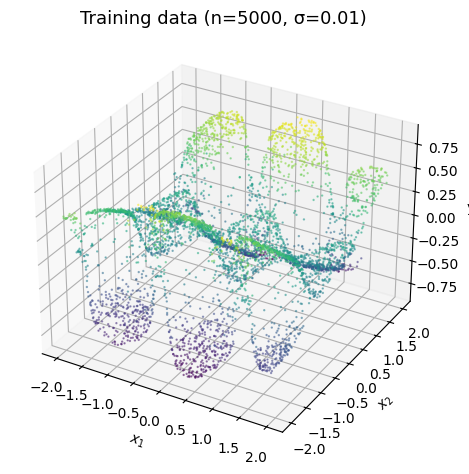

In [47]:
set_seed(SEED)
n_base = 5000
X_tr, y_tr, X_cal, y_cal, X_te, y_te = generate_data(
    n_base, n_cal=1000, n_test=2000, sigma=0.01, seed=0)

for name, X, y in [('Train', X_tr, y_tr), ('Cal', X_cal, y_cal), ('Test', X_te, y_te)]:
    print(f'{name}: X={X.shape}  y_range=[{y.min():.3f}, {y.max():.3f}]')

# 3D scatter of training data
ax = plt.axes(projection='3d')
ax.scatter(X_tr[:,0], X_tr[:,1], y_tr, marker='.', c=y_tr, cmap='viridis', s=2, alpha=0.5)
ax.set_title(f'Training data (n={n_base}, σ=0.01)', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_zlabel('y')
plt.tight_layout(); plt.show()

Per-layer gammas (baseline X_tr): γ₁=0.4881  γ₂=3.3864
DNN            : train=0.00939  test=0.01022  ep=2000  292.5s  mem=21.4MB
ResNet         : train=0.00563  test=0.00571  ep=2000  219.3s  mem=0.7MB
MLKM           : train=0.01922  test=0.01873  ep=2000  185.1s  mem=1.0MB
ResKernelNet   : train=0.02034  test=0.01894  ep=2000  204.4s  mem=0.9MB


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


DKL            : train=0.00496  test=0.00795  180.7s  mem=1.9MB
DGP            : train=0.00089  test=0.00099  922.9s  mem=1.0MB



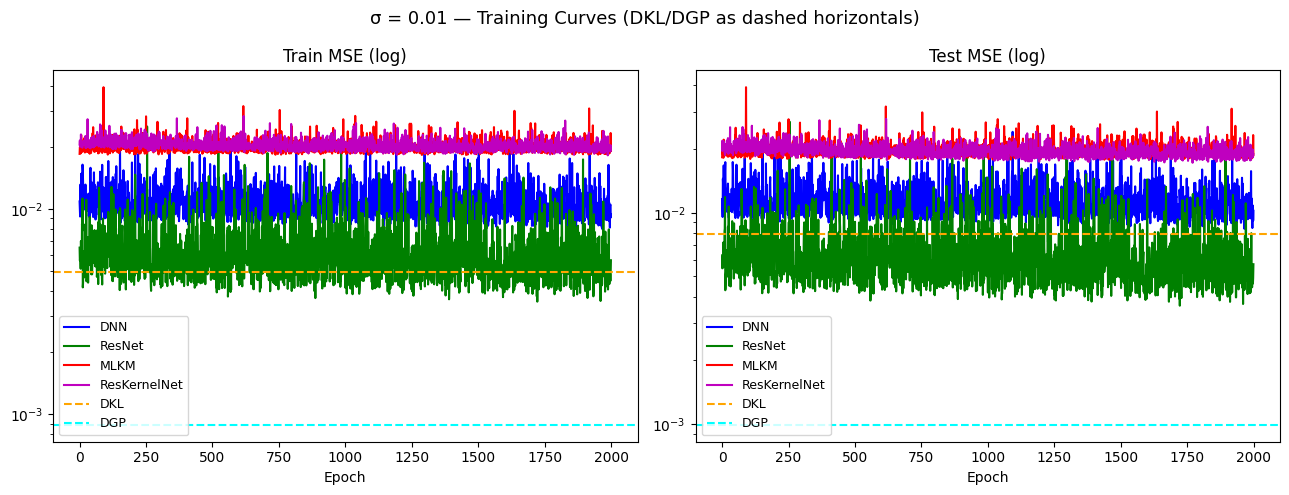

In [48]:
# Pre-compute per-layer gammas BEFORE memory measurement (fair comparison).
_base_g1, _base_g2 = _compute_per_layer_gammas(X_tr, D=D_DEF)
print(f'Per-layer gammas (baseline X_tr): γ₁={_base_g1:.4f}  γ₂={_base_g2:.4f}')

models_spec = [
    ('DNN',          lambda: DNN()),
    ('ResNet',       lambda: ResNet()),
    ('MLKM',         lambda g=(_base_g1, _base_g2): KernelNet(D=D_DEF, gammas=g)),
    ('ResKernelNet', lambda g=(_base_g1, _base_g2): ResKernelNet(D1=D_DEF, gammas=g)),
]

baseline_nets = {}; baseline_opts = {}; baseline_results = []

# ── NN models ────────────────────────────────────────────────────────────────
for label, make_net in models_spec:
    set_seed(SEED)
    net = make_net(); net.apply(init_weights)
    def _run(n=net): return train_model(n, X_tr, y_tr, X_te, y_te, verbose=False)
    t0 = time.time()
    result, _, cpu_peak = measure_memory_cpu(_run)
    dt = time.time() - t0
    net, opt, trl, tel = result
    baseline_nets[label] = (net, trl, tel)
    baseline_opts[label] = opt
    print(f'{label:15s}: train={trl[-1]:.5f}  test={tel[-1]:.5f}  '
          f'ep={len(trl):4d}  {dt:.1f}s  mem={cpu_peak:.1f}MB')
    baseline_results.append({'Method': label, 'Train MSE': trl[-1],
                              'Test MSE': tel[-1], 'Time (s)': dt, 'CPU Peak (MB)': cpu_peak})

# ── DKL ──────────────────────────────────────────────────────────────────────
set_seed(SEED)
t0 = time.time()
(dkl_tr, dkl_te, dkl_pred), _, dkl_mem = measure_memory_cpu(
    run_dkl, X_tr, y_tr, X_te, y_te)
dkl_time = time.time() - t0
baseline_nets['DKL'] = (dkl_pred, None, None)
print(f'{"DKL":15s}: train={dkl_tr:.5f}  test={dkl_te:.5f}  {dkl_time:.1f}s  mem={dkl_mem:.1f}MB')
baseline_results.append({'Method': 'DKL', 'Train MSE': dkl_tr, 'Test MSE': dkl_te,
                          'Time (s)': dkl_time, 'CPU Peak (MB)': dkl_mem})

# ── DGP ──────────────────────────────────────────────────────────────────────
set_seed(SEED)
t0 = time.time()
(dgp_tr, dgp_te, dgp_pred), _, dgp_mem = measure_memory_cpu(
    run_dgp, X_tr, y_tr, X_te, y_te)
dgp_time = time.time() - t0
baseline_nets['DGP'] = (dgp_pred, None, None)
print(f'{"DGP":15s}: train={dgp_tr:.5f}  test={dgp_te:.5f}  {dgp_time:.1f}s  mem={dgp_mem:.1f}MB')
baseline_results.append({'Method': 'DGP', 'Train MSE': dgp_tr, 'Test MSE': dgp_te,
                          'Time (s)': dgp_time, 'CPU Peak (MB)': dgp_mem})

# ── Training curves: NN models as lines, DKL/DGP as dashed horizontals ──────
print()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nn_styles = {'DNN': ('b', '-'), 'ResNet': ('g', '-'),
             'MLKM': ('r', '-'), 'ResKernelNet': ('m', '-')}
for label, (net, trl, tel) in baseline_nets.items():
    if trl is None: continue
    c, ls = nn_styles[label]
    axes[0].plot(trl, color=c, ls=ls, label=label)
    axes[1].plot(tel, color=c, ls=ls, label=label)
axes[0].axhline(dkl_tr, color='orange', ls='--', lw=1.5, label='DKL')
axes[1].axhline(dkl_te, color='orange', ls='--', lw=1.5, label='DKL')
axes[0].axhline(dgp_tr, color='cyan',   ls='--', lw=1.5, label='DGP')
axes[1].axhline(dgp_te, color='cyan',   ls='--', lw=1.5, label='DGP')
for ax, title in zip(axes, ['Train MSE (log)', 'Test MSE (log)']):
    ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle('σ = 0.01 — Training Curves (DKL/DGP as dashed horizontals)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec1_training_curves_sigma001.png'), dpi=120, bbox_inches='tight')
plt.show()

In [49]:
# ── Split conformal for all 6 models (σ=0.01) ─────────────────────────────
conf_results = []
for label, (net, trl, _) in baseline_nets.items():
    cov, lng, q = conformal_split(net, X_cal, y_cal, X_te, y_te)
    row = {'Method': label, 'Split Cov': cov, 'Split Interval': lng, 'Split q_hat': q}
    print(f'{label:15s}  split: cov={cov:.4f}  interval={lng:.4f}')
    if label in ('MLKM', 'ResKernelNet'):
        opt = baseline_opts[label]
        cov_h, lng_h, a_h = hetero_conformal(
            net, opt, X_tr, X_cal, y_cal, X_te, y_te, trl[-1])
        row['Hetero Cov'] = cov_h; row['Hetero Interval'] = lng_h
        print(f'  {"":15s}  hetero: cov={cov_h:.4f}  interval={lng_h:.4f}')
    conf_results.append(row)

conf_df = pd.DataFrame(conf_results)
results_df = pd.DataFrame(baseline_results)
print('\n── Summary (σ=0.01) ──')
print(results_df.round(5).to_string(index=False))
print()
print(conf_df.round(4).to_string(index=False))
results_df.to_csv(os.path.join(RESULTS_DIR, 'sec1_baseline_sigma001.csv'), index=False)
conf_df.to_csv(os.path.join(RESULTS_DIR, 'sec1_conformal_sigma001.csv'), index=False)

DNN              split: cov=0.9435  interval=0.4099
ResNet           split: cov=0.9585  interval=0.3228
MLKM             split: cov=0.9570  interval=0.5569
                   hetero: cov=0.9449  interval=0.5149
ResKernelNet     split: cov=0.9630  interval=0.5929
                   hetero: cov=0.9655  interval=0.5849
DKL              split: cov=0.9465  interval=0.4015
DGP              split: cov=0.9515  interval=0.1246

── Summary (σ=0.01) ──
      Method  Train MSE  Test MSE  Time (s)  CPU Peak (MB)
         DNN    0.00939   0.01022 292.53700       21.43750
      ResNet    0.00563   0.00571 219.28725        0.71875
        MLKM    0.01922   0.01873 185.09306        0.95312
ResKernelNet    0.02034   0.01894 204.40488        0.90625
         DKL    0.00496   0.00795 180.70731        1.87500
         DGP    0.00089   0.00099 922.88637        1.01562

      Method  Split Cov  Split Interval  Split q_hat  Hetero Cov  Hetero Interval
         DNN     0.9435          0.4099       0.2050      

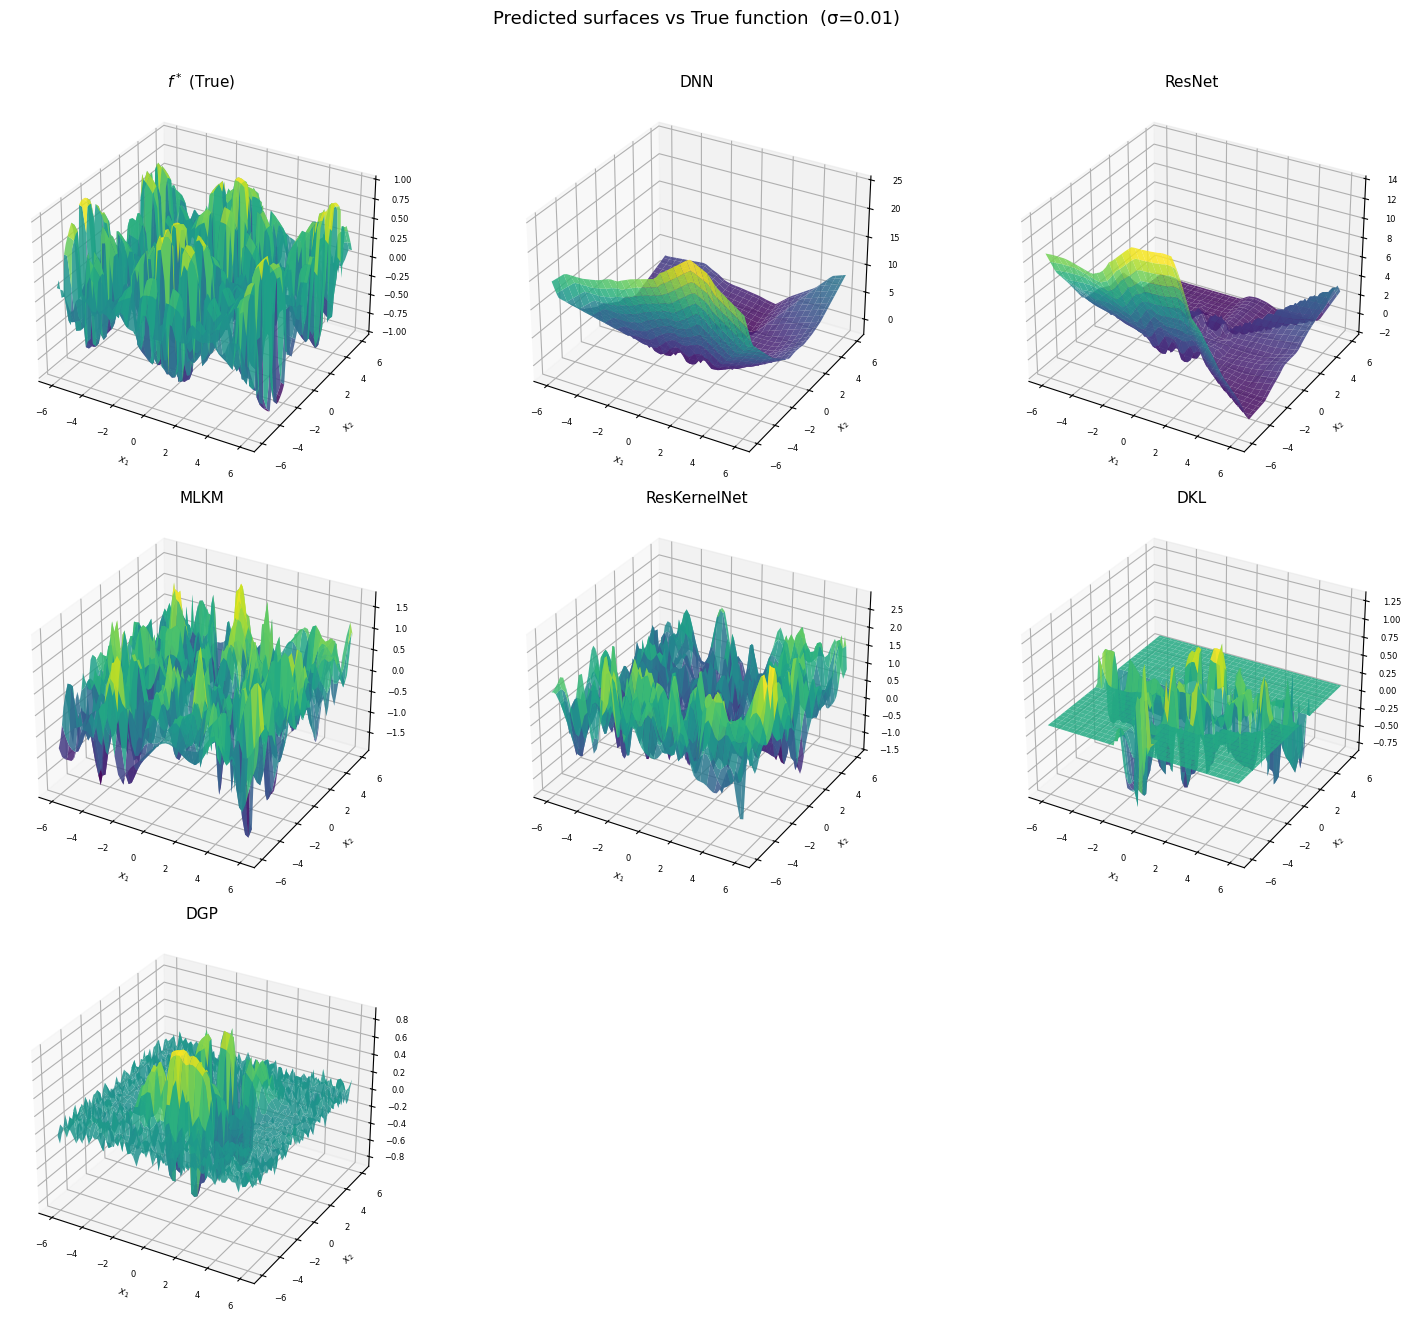

In [50]:
# ── Prediction surfaces — 3×3 grid: f* (True) + 6 methods (σ=0.01) ──────────
xx_g = np.linspace(-6, 6, 60)
xx2, yy2 = np.meshgrid(xx_g, xx_g)
X_grid   = np.column_stack([xx2.ravel(), yy2.ravel()]).astype('float32')
X_grid_t = torch.from_numpy(X_grid)
Z_true   = f_star(X_grid).reshape(60, 60)

panels = [('$f^*$ (True)', Z_true)]
for label in ['DNN', 'ResNet', 'MLKM', 'ResKernelNet']:
    net = baseline_nets[label][0]; net.eval()
    with torch.no_grad():
        panels.append((label, net(X_grid_t).numpy().reshape(60, 60)))
for label in ['DKL', 'DGP']:
    pred_fn = baseline_nets[label][0]
    with torch.no_grad():
        panels.append((label, pred_fn(X_grid_t).numpy().reshape(60, 60)))

fig = plt.figure(figsize=(15, 13))
for idx, (title, Z) in enumerate(panels):
    ax = fig.add_subplot(3, 3, idx + 1, projection='3d')
    ax.plot_surface(xx2, yy2, Z, cmap='viridis', alpha=0.85)
    ax.set_title(title, fontsize=11, pad=4)
    ax.set_xlabel('$x_1$', fontsize=7, labelpad=2)
    ax.set_ylabel('$x_2$', fontsize=7, labelpad=2)
    ax.tick_params(labelsize=6)
for unused in [8, 9]:
    fig.add_subplot(3, 3, unused).set_visible(False)
plt.suptitle('Predicted surfaces vs True function  (σ=0.01)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec1_prediction_surfaces_sigma001.png'), dpi=120, bbox_inches='tight')
plt.show()

### σ = 0.1 (higher noise)

DNN            : train=0.02088  test=0.02255  ep=2000  214.3s  mem=1.3MB
ResNet         : train=0.02289  test=0.02470  ep=2000  273.2s  mem=0.8MB
MLKM           : train=0.03301  test=0.03307  ep=2000  217.9s  mem=0.8MB
ResKernelNet   : train=0.02708  test=0.02748  ep=2000  224.0s  mem=0.9MB


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


DKL            : train=0.01834  test=0.02682  233.1s  mem=0.7MB
DGP            : train=0.01165  test=0.01225  821.8s  mem=1.2MB


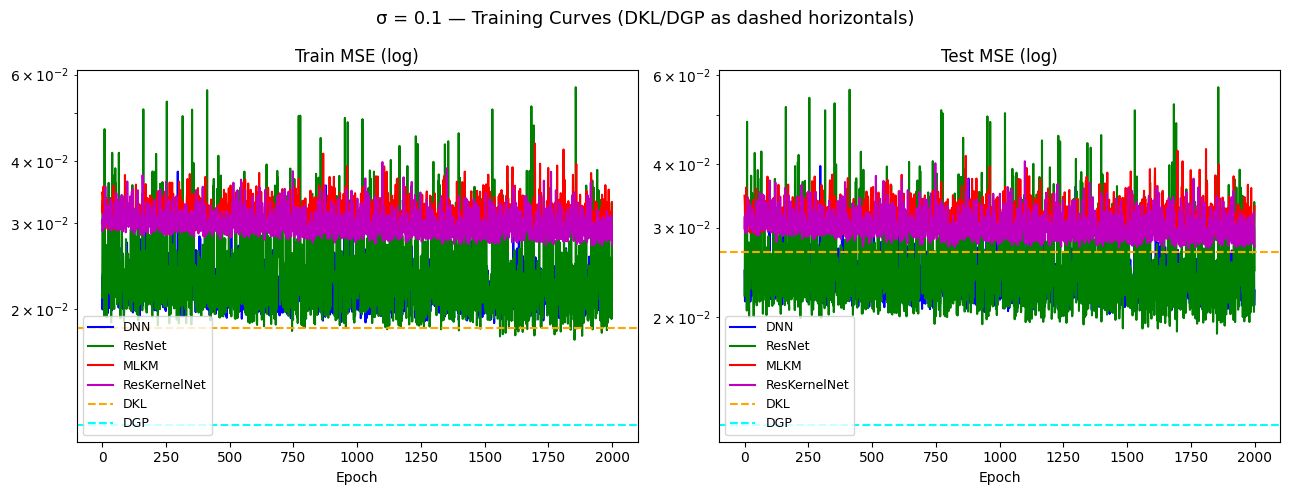

DNN              split: cov=0.9330  interval=0.5603
ResNet           split: cov=0.9445  interval=0.6146
MLKM             split: cov=0.9340  interval=0.6747
ResKernelNet     split: cov=0.9425  interval=0.6397
DKL              split: cov=0.9510  interval=0.6433
DGP              split: cov=0.9395  interval=0.4201

── Summary (σ=0.1) ──
      Method  Train MSE  Test MSE  Time (s)  CPU Peak (MB)
         DNN    0.02088   0.02255 214.26950        1.28125
      ResNet    0.02289   0.02470 273.18296        0.76562
        MLKM    0.03301   0.03307 217.94610        0.75000
ResKernelNet    0.02708   0.02748 223.99423        0.89062
         DKL    0.01834   0.02682 233.09334        0.67188
         DGP    0.01165   0.01225 821.77516        1.23438

      Method  Split Cov  Split Interval  Hetero Cov  Hetero Interval
         DNN     0.9330          0.5603         NaN              NaN
      ResNet     0.9445          0.6146         NaN              NaN
        MLKM     0.9340          0.6747     

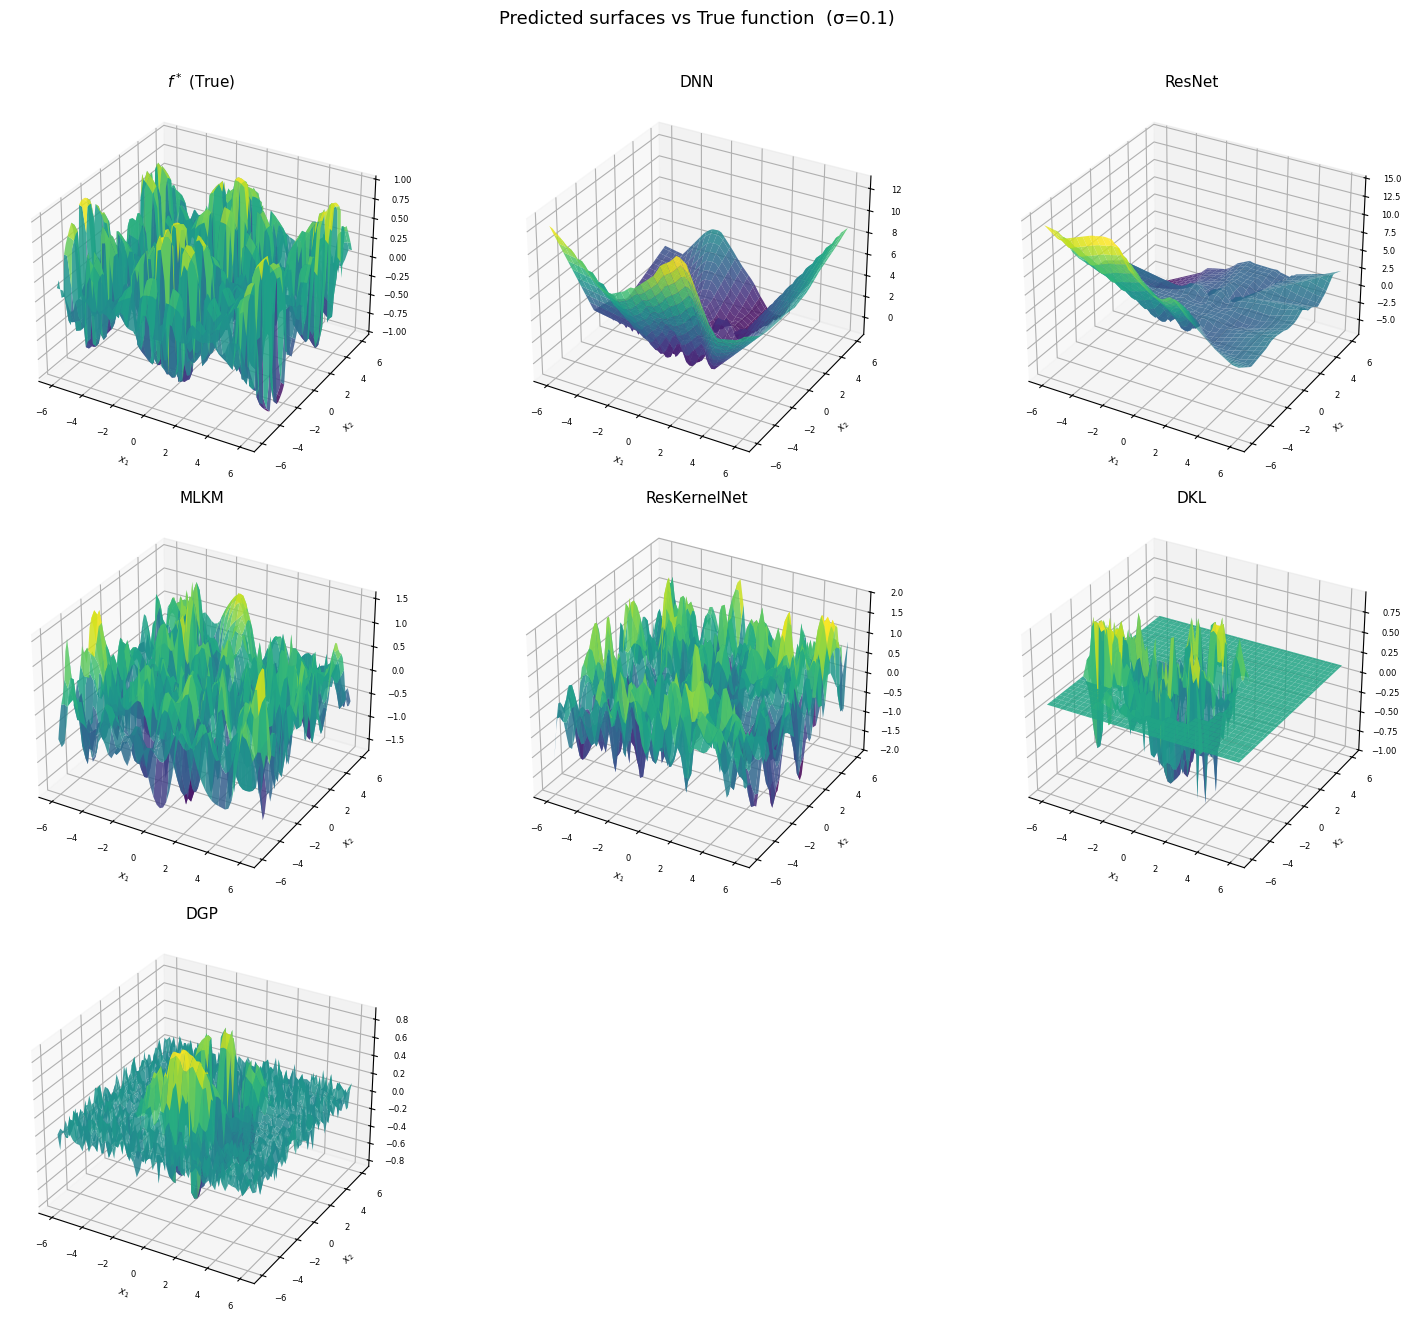

In [51]:
set_seed(SEED)
X_tr1, y_tr1, X_cal1, y_cal1, X_te1, y_te1 = generate_data(
    n_base, n_cal=1000, n_test=2000, sigma=0.1, seed=0)

noise_nets = {}; noise_opts = {}; noise_results = []
for label, make_net in models_spec:
    set_seed(SEED)
    net = make_net(); net.apply(init_weights)
    def _run1(n=net): return train_model(n, X_tr1, y_tr1, X_te1, y_te1, verbose=False)
    t0 = time.time()
    result, _, cpu_peak = measure_memory_cpu(_run1)
    dt = time.time() - t0
    net, opt, trl, tel = result
    noise_nets[label] = (net, trl, tel); noise_opts[label] = opt
    print(f'{label:15s}: train={trl[-1]:.5f}  test={tel[-1]:.5f}  '
          f'ep={len(trl):4d}  {dt:.1f}s  mem={cpu_peak:.1f}MB')
    noise_results.append({'Method': label, 'Train MSE': trl[-1],
                          'Test MSE': tel[-1], 'Time (s)': dt, 'CPU Peak (MB)': cpu_peak})

set_seed(SEED)
t0 = time.time()
(dkl_tr1, dkl_te1, dkl_pred1), _, dkl_mem1 = measure_memory_cpu(
    run_dkl, X_tr1, y_tr1, X_te1, y_te1)
dkl_time1 = time.time() - t0
noise_nets['DKL'] = (dkl_pred1, None, None)
noise_results.append({'Method': 'DKL', 'Train MSE': dkl_tr1, 'Test MSE': dkl_te1,
                       'Time (s)': dkl_time1, 'CPU Peak (MB)': dkl_mem1})
print(f'{"DKL":15s}: train={dkl_tr1:.5f}  test={dkl_te1:.5f}  {dkl_time1:.1f}s  mem={dkl_mem1:.1f}MB')

set_seed(SEED)
t0 = time.time()
(dgp_tr1, dgp_te1, dgp_pred1), _, dgp_mem1 = measure_memory_cpu(
    run_dgp, X_tr1, y_tr1, X_te1, y_te1)
dgp_time1 = time.time() - t0
noise_nets['DGP'] = (dgp_pred1, None, None)
noise_results.append({'Method': 'DGP', 'Train MSE': dgp_tr1, 'Test MSE': dgp_te1,
                       'Time (s)': dgp_time1, 'CPU Peak (MB)': dgp_mem1})
print(f'{"DGP":15s}: train={dgp_tr1:.5f}  test={dgp_te1:.5f}  {dgp_time1:.1f}s  mem={dgp_mem1:.1f}MB')

# ── Training curves σ=0.1 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, (net, trl, tel) in noise_nets.items():
    if trl is None: continue
    c, ls = nn_styles[label]
    axes[0].plot(trl, color=c, ls=ls, label=label)
    axes[1].plot(tel, color=c, ls=ls, label=label)
axes[0].axhline(dkl_tr1, color='orange', ls='--', lw=1.5, label='DKL')
axes[1].axhline(dkl_te1, color='orange', ls='--', lw=1.5, label='DKL')
axes[0].axhline(dgp_tr1, color='cyan',   ls='--', lw=1.5, label='DGP')
axes[1].axhline(dgp_te1, color='cyan',   ls='--', lw=1.5, label='DGP')
for ax, title in zip(axes, ['Train MSE (log)', 'Test MSE (log)']):
    ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle('σ = 0.1 — Training Curves (DKL/DGP as dashed horizontals)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec1_training_curves_sigma01.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── Conformal σ=0.1 ──────────────────────────────────────────────────────────
noise_conf_results = []
for label, (net, trl, _) in noise_nets.items():
    cov, lng, q = conformal_split(net, X_cal1, y_cal1, X_te1, y_te1)
    row = {'Method': label, 'Split Cov': cov, 'Split Interval': lng}
    if label in ('MLKM', 'ResKernelNet'):
        cov_h, lng_h, _ = hetero_conformal(
            net, noise_opts[label], X_tr1, X_cal1, y_cal1, X_te1, y_te1, trl[-1])
        row['Hetero Cov'] = cov_h; row['Hetero Interval'] = lng_h
    noise_conf_results.append(row)
    print(f'{label:15s}  split: cov={cov:.4f}  interval={lng:.4f}')

noise_results_df = pd.DataFrame(noise_results)
noise_conf_df    = pd.DataFrame(noise_conf_results)
print('\n── Summary (σ=0.1) ──')
print(noise_results_df.round(5).to_string(index=False))
print(); print(noise_conf_df.round(4).to_string(index=False))
noise_results_df.to_csv(os.path.join(RESULTS_DIR, 'sec1_baseline_sigma01.csv'), index=False)
noise_conf_df.to_csv(os.path.join(RESULTS_DIR, 'sec1_conformal_sigma01.csv'), index=False)

# ── Prediction surfaces σ=0.1 ─────────────────────────────────────────────────
X_grid1   = np.column_stack([xx2.ravel(), yy2.ravel()]).astype('float32')
X_grid1_t = torch.from_numpy(X_grid1)
Z_true1   = f_star(X_grid1).reshape(60, 60)
panels1   = [('$f^*$ (True)', Z_true1)]
for label in ['DNN', 'ResNet', 'MLKM', 'ResKernelNet']:
    net = noise_nets[label][0]; net.eval()
    with torch.no_grad():
        panels1.append((label, net(X_grid1_t).numpy().reshape(60, 60)))
for label in ['DKL', 'DGP']:
    pred_fn = noise_nets[label][0]
    with torch.no_grad():
        panels1.append((label, pred_fn(X_grid1_t).numpy().reshape(60, 60)))
fig = plt.figure(figsize=(15, 13))
for idx, (title, Z1) in enumerate(panels1):
    ax = fig.add_subplot(3, 3, idx + 1, projection='3d')
    ax.plot_surface(xx2, yy2, Z1, cmap='viridis', alpha=0.85)
    ax.set_title(title, fontsize=11, pad=4)
    ax.set_xlabel('$x_1$', fontsize=7, labelpad=2)
    ax.set_ylabel('$x_2$', fontsize=7, labelpad=2)
    ax.tick_params(labelsize=6)
for unused in [8, 9]:
    fig.add_subplot(3, 3, unused).set_visible(False)
plt.suptitle('Predicted surfaces vs True function  (σ=0.1)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec1_prediction_surfaces_sigma01.png'), dpi=120, bbox_inches='tight')
plt.show()

In [52]:
# ── Side-by-side comparison: σ=0.01 vs σ=0.1 ─────────────────────────────────
print('─' * 65)
print('  Comparison: σ=0.01 vs σ=0.1  (Test MSE)')
print('─' * 65)
for (r1, r2) in zip(baseline_results, noise_results):
    print(f"  {r1['Method']:15s}  σ=0.01: {r1['Test MSE']:.5f}   σ=0.1: {r2['Test MSE']:.5f}")
print()
print('Conformal intervals (Split):')
for (c1, c2) in zip(conf_results, noise_conf_results):
    print(f"  {c1['Method']:15s}  σ=0.01: {c1['Split Interval']:.4f}"
          f"   σ=0.1: {c2['Split Interval']:.4f}")

─────────────────────────────────────────────────────────────────
  Comparison: σ=0.01 vs σ=0.1  (Test MSE)
─────────────────────────────────────────────────────────────────
  DNN              σ=0.01: 0.01022   σ=0.1: 0.02255
  ResNet           σ=0.01: 0.00571   σ=0.1: 0.02470
  MLKM             σ=0.01: 0.01873   σ=0.1: 0.03307
  ResKernelNet     σ=0.01: 0.01894   σ=0.1: 0.02748
  DKL              σ=0.01: 0.00795   σ=0.1: 0.02682
  DGP              σ=0.01: 0.00099   σ=0.1: 0.01225

Conformal intervals (Split):
  DNN              σ=0.01: 0.4099   σ=0.1: 0.5603
  ResNet           σ=0.01: 0.3228   σ=0.1: 0.6146
  MLKM             σ=0.01: 0.5569   σ=0.1: 0.6747
  ResKernelNet     σ=0.01: 0.5929   σ=0.1: 0.6397
  DKL              σ=0.01: 0.4015   σ=0.1: 0.6433
  DGP              σ=0.01: 0.1246   σ=0.1: 0.4201


## Section 2: Sample Size Experiment

Run for both σ=0.01 and σ=0.1. For each n ∈ {200, 500, 1000, 2000, 5000}, measure:
- Test MSE
- Split conformal interval length
- Training time

**Hypothesis:** MLKM's advantage over DGP should grow with n, as more data reveals the
multi-scale structure that DGP's single kernel cannot decompose.

In [53]:
def _run_sample_size_experiment(sigma_val):
    """Run n-sweep for one sigma value. Returns DataFrame."""
    rng_shared = np.random.RandomState(999)
    X_cal_sh = rng_shared.uniform(-6, 6, (1000, 2)).astype('float32')
    y_cal_sh = f_star(X_cal_sh) + (sigma_val * rng_shared.randn(1000)).astype('float32')
    X_te_sh  = rng_shared.uniform(-6, 6, (2000, 2)).astype('float32')
    y_te_sh  = f_star(X_te_sh)  + (sigma_val * rng_shared.randn(2000)).astype('float32')

    n_results_loc = []
    print(f'\n{"="*55}')
    print(f'  Sample-size sweep  σ={sigma_val}')
    print(f'{"="*55}')
    for n in N_SIZES:
        rng_n = np.random.RandomState(n)
        X_n = rng_n.uniform(-6, 6, (n, 2)).astype('float32')
        y_n = f_star(X_n) + (sigma_val * rng_n.randn(n)).astype('float32')
        row = {'n': n}
        _g1_n, _g2_n = _compute_per_layer_gammas(X_n, D=D_DEF)
        _local_spec = [
            ('DNN',          lambda: DNN()),
            ('ResNet',       lambda: ResNet()),
            ('MLKM',         lambda g=(_g1_n, _g2_n): KernelNet(D=D_DEF, gammas=g)),
            ('ResKernelNet', lambda g=(_g1_n, _g2_n): ResKernelNet(D1=D_DEF, gammas=g)),
        ]
        for lbl, make_net in _local_spec:
            set_seed(SEED)
            net = make_net(); net.apply(init_weights)
            t0 = time.time()
            net, opt, trl, tel = train_model(net, X_n, y_n, X_te_sh, y_te_sh, verbose=False)
            row[f'{lbl}_time'] = time.time() - t0
            cov, lng, _ = conformal_split(net, X_cal_sh, y_cal_sh, X_te_sh, y_te_sh)
            row[f'{lbl}_test'] = tel[-1]; row[f'{lbl}_interval'] = lng
            print(f'  n={n:5d}  {lbl:15s}: test={tel[-1]:.5f}  interval={lng:.4f}  t={row[f"{lbl}_time"]:.1f}s')
        # DKL
        t0 = time.time()
        dkl_tr_n, dkl_te_n, dkl_pred_n = run_dkl(X_n, y_n, X_te_sh, y_te_sh)
        row['DKL_time'] = time.time() - t0
        cov, lng, _ = conformal_split(dkl_pred_n, X_cal_sh, y_cal_sh, X_te_sh, y_te_sh)
        row['DKL_test'] = dkl_te_n; row['DKL_interval'] = lng
        print(f'  n={n:5d}  {"DKL":15s}: test={dkl_te_n:.5f}  interval={lng:.4f}  t={row["DKL_time"]:.1f}s')
        # DGP
        t0 = time.time()
        dgp_tr_n, dgp_te_n, dgp_pred_n = run_dgp(X_n, y_n, X_te_sh, y_te_sh)
        row['DGP_time'] = time.time() - t0
        cov, lng, _ = conformal_split(dgp_pred_n, X_cal_sh, y_cal_sh, X_te_sh, y_te_sh)
        row['DGP_test'] = dgp_te_n; row['DGP_interval'] = lng
        print(f'  n={n:5d}  {"DGP":15s}: test={dgp_te_n:.5f}  interval={lng:.4f}  t={row["DGP_time"]:.1f}s')
        n_results_loc.append(row)

    df = pd.DataFrame(n_results_loc)
    print(); print(df.round(4).to_string(index=False))
    return df

n_df    = _run_sample_size_experiment(0.01)
n_df_01 = _run_sample_size_experiment(0.1)


  Sample-size sweep  σ=0.01
  n=  200  DNN            : test=0.20835  interval=1.8966  t=3.0s
  n=  200  ResNet         : test=0.20299  interval=1.8588  t=3.8s
  n=  200  MLKM           : test=0.22885  interval=2.0251  t=3.6s
  n=  200  ResKernelNet   : test=0.20310  interval=1.7679  t=3.7s


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  n=  200  DKL            : test=0.23212  interval=1.9931  t=0.3s
  n=  200  DGP            : test=0.18186  interval=1.7265  t=8.4s
  n=  500  DNN            : test=0.18515  interval=1.7593  t=5.4s
  n=  500  ResNet         : test=0.18608  interval=1.6881  t=6.7s
  n=  500  MLKM           : test=0.19742  interval=1.7533  t=5.9s
  n=  500  ResKernelNet   : test=0.19417  interval=1.7057  t=6.6s


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  n=  500  DKL            : test=0.18397  interval=1.7422  t=0.6s
  n=  500  DGP            : test=0.18130  interval=1.7300  t=20.4s
  n= 1000  DNN            : test=0.18687  interval=1.7138  t=9.7s
  n= 1000  ResNet         : test=0.17966  interval=1.7555  t=12.2s
  n= 1000  MLKM           : test=0.19134  interval=1.7730  t=10.3s
  n= 1000  ResKernelNet   : test=0.18506  interval=1.7760  t=11.5s


...

  n= 1000  DKL            : test=0.19662  interval=1.8074  t=3.0s
  n= 1000  DGP            : test=0.18774  interval=1.7722  t=83.2s
  n= 2000  DNN            : test=0.18246  interval=1.8078  t=22.8s
  n= 2000  ResNet         : test=0.16039  interval=1.6657  t=27.5s
  n= 2000  MLKM           : test=0.15991  interval=1.7853  t=21.8s
  n= 2000  ResKernelNet   : test=0.15637  interval=1.6012  t=23.9s


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  n= 2000  DKL            : test=0.15300  interval=1.6406  t=7.8s
  n= 2000  DGP            : test=0.18787  interval=1.7719  t=92.6s
  n= 5000  DNN            : test=0.14833  interval=1.5780  t=49.3s
  n= 5000  ResNet         : test=0.13696  interval=1.5502  t=59.8s
  n= 5000  MLKM           : test=0.14970  interval=1.6204  t=49.9s
  n= 5000  ResKernelNet   : test=0.15841  interval=1.7340  t=55.1s


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  n= 5000  DKL            : test=0.09330  interval=1.3424  t=56.3s
  n= 5000  DGP            : test=0.11408  interval=1.4946  t=227.5s

   n  DNN_time  DNN_test  DNN_interval  ResNet_time  ResNet_test  ResNet_interval  MLKM_time  MLKM_test  MLKM_interval  ResKernelNet_time  ResKernelNet_test  ResKernelNet_interval  DKL_time  DKL_test  DKL_interval  DGP_time  DGP_test  DGP_interval
 200    6.2050    0.2137        1.9744       7.6478       0.2202           1.9977     7.1107     0.2262         2.0524             7.9188             0.2206                 1.9388    0.5936    0.2553        2.1467   18.0010    0.1883        1.7651
 500   11.8757    0.1951        1.8413      16.3811       0.1926           1.8306    12.9952     0.2051         1.8236            14.1961             0.2022                 1.8062    1.7421    0.1958        1.8394   43.2678    0.1878        1.7660
1000   20.5788    0.1941        1.8413      25.3158       0.1668           1.6502    21.2231     0.1947         1.8398  

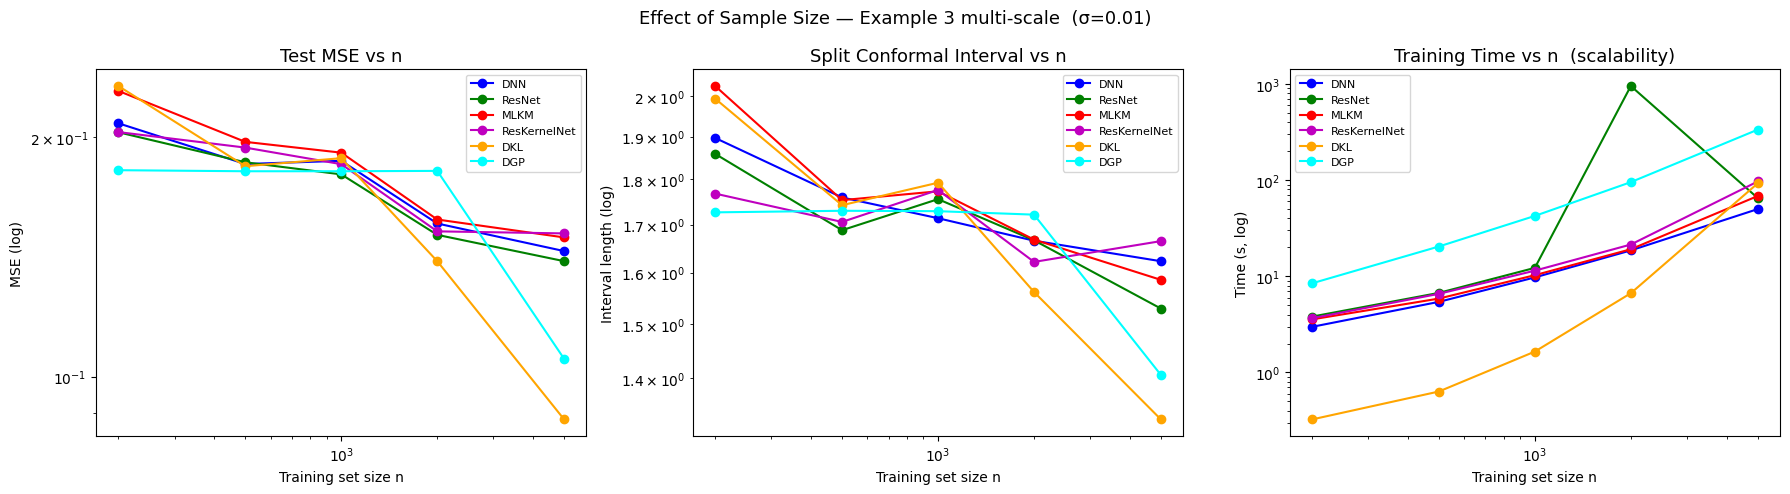

Saved → ex3_results/sec2_sigma001_sample_size.png  &  ex3_results/sec2_sigma001_sample_size_results.csv

Interval ratio (MLKM / DGP)  [σ=0.01]:
   n    ratio
 200 1.172949
 500 1.013515
1000 1.025400
2000 0.968968
5000 1.127593


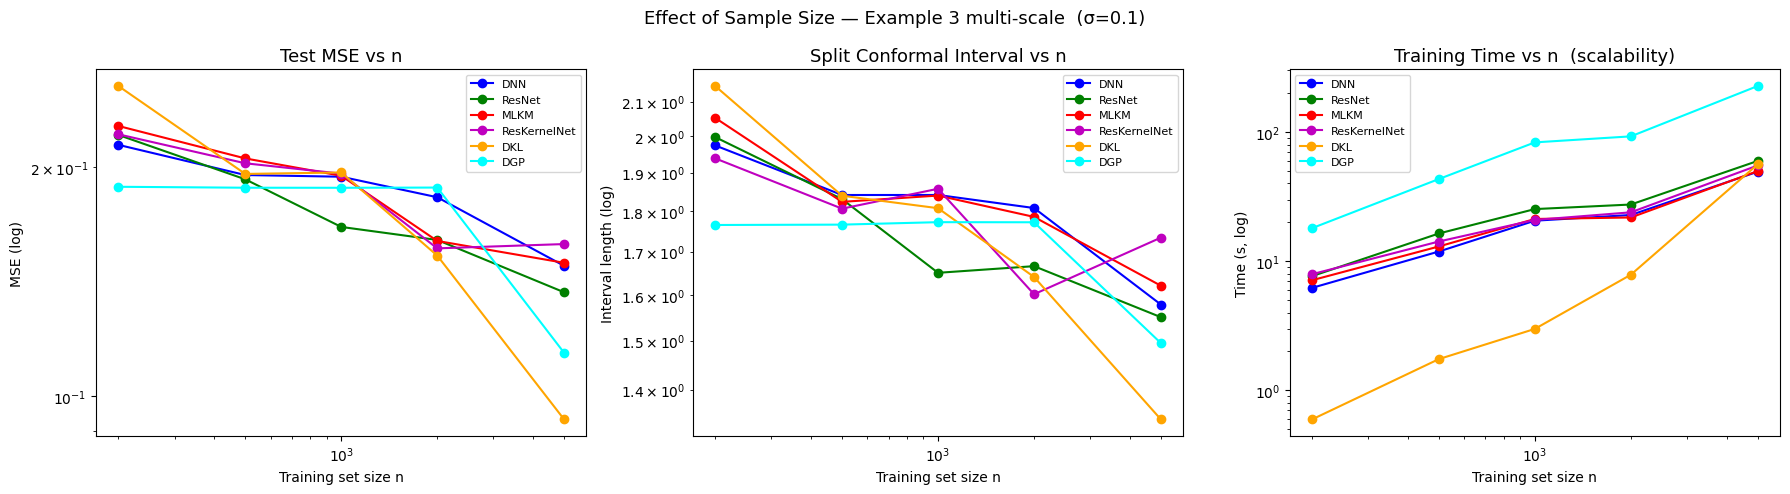

Saved → ex3_results/sec2_sigma01_sample_size.png  &  ex3_results/sec2_sigma01_sample_size_results.csv

Interval ratio (MLKM / DGP)  [σ=0.1]:
   n    ratio
 200 1.162754
 500 1.032588
1000 1.038168
2000 1.007577
5000 1.084208


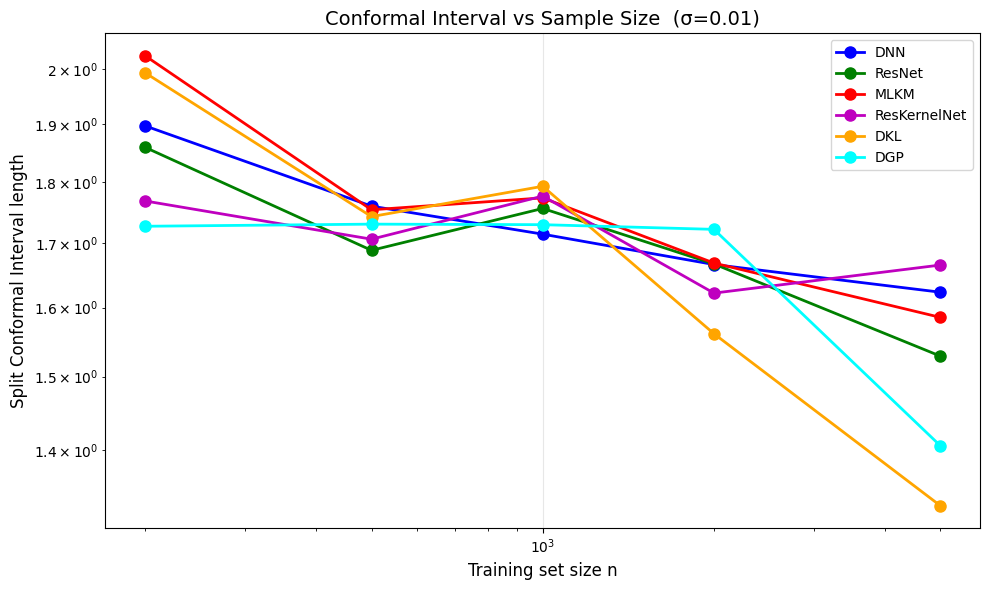

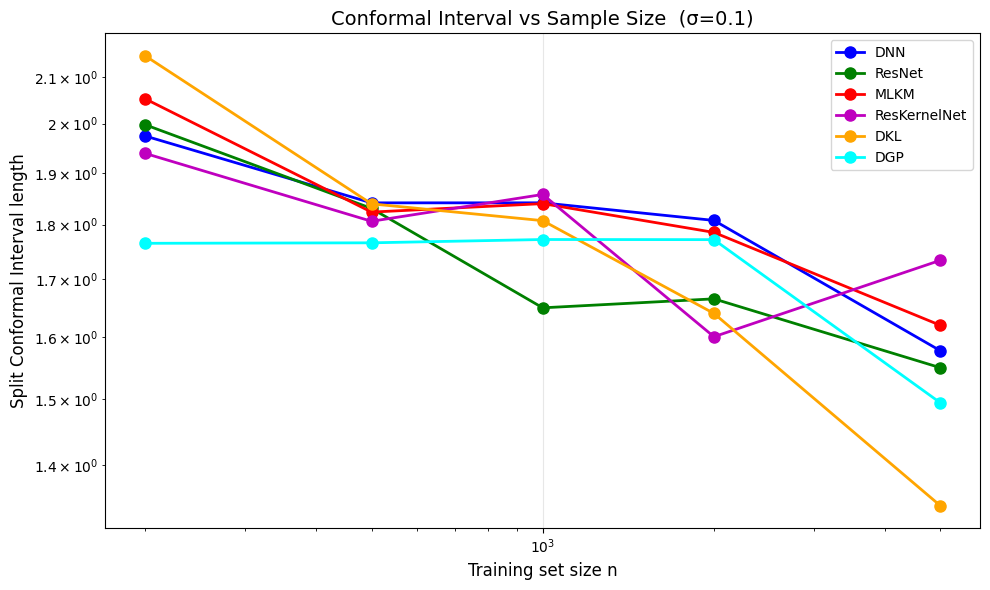

In [54]:
colors = {'DNN':'b','ResNet':'g','MLKM':'r','ResKernelNet':'m','DKL':'orange','DGP':'cyan'}

def _plot_sample_size(df, sigma_label, fname_prefix):
    ns = df['n'].values
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for label, c in colors.items():
        axes[0].plot(ns, df[f'{label}_test'],     marker='o', ls='-', color=c, label=label)
        axes[1].plot(ns, df[f'{label}_interval'], marker='o', ls='-', color=c, label=label)
        axes[2].plot(ns, df[f'{label}_time'],     marker='o', ls='-', color=c, label=label)
    axes[0].set_title('Test MSE vs n', fontsize=13)
    axes[1].set_title('Split Conformal Interval vs n', fontsize=13)
    axes[2].set_title('Training Time vs n  (scalability)', fontsize=13)
    for ax in axes:
        ax.set_xlabel('Training set size n'); ax.legend(fontsize=8); ax.set_xscale('log')
    axes[0].set_yscale('log'); axes[1].set_yscale('log'); axes[2].set_yscale('log')
    axes[0].set_ylabel('MSE (log)'); axes[1].set_ylabel('Interval length (log)')
    axes[2].set_ylabel('Time (s, log)')
    plt.suptitle(f'Effect of Sample Size — Example 3 multi-scale  (σ={sigma_label})', fontsize=13)
    plt.tight_layout()
    png_path = os.path.join(RESULTS_DIR, f'{fname_prefix}_sample_size.png')
    plt.savefig(png_path, dpi=120, bbox_inches='tight'); plt.show()
    csv_path = os.path.join(RESULTS_DIR, f'{fname_prefix}_sample_size_results.csv')
    df.to_csv(csv_path, index=False)
    print(f'Saved → {png_path}  &  {csv_path}')
    print(f'\nInterval ratio (MLKM / DGP)  [σ={sigma_label}]:')
    print(df[['n']].assign(ratio=(df['MLKM_interval']/df['DGP_interval'])).to_string(index=False))

def _plot_conformal_interval(df, sigma_label, fname_prefix):
    ns = df['n'].values
    fig2, ax = plt.subplots(figsize=(10, 6))
    for label, c in colors.items():
        ax.plot(ns, df[f'{label}_interval'], marker='o', ls='-', color=c,
                label=label, linewidth=2, markersize=8)
    ax.set_xlabel('Training set size n', fontsize=12)
    ax.set_ylabel('Split Conformal Interval length', fontsize=12)
    ax.set_title(f'Conformal Interval vs Sample Size  (σ={sigma_label})', fontsize=14)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f'{fname_prefix}_conformal_interval_vs_n.png')
    plt.savefig(path, dpi=120, bbox_inches='tight'); plt.show()

_plot_sample_size(n_df,    '0.01', 'sec2_sigma001')
_plot_sample_size(n_df_01, '0.1',  'sec2_sigma01')
_plot_conformal_interval(n_df,    '0.01', 'sec2_sigma001')
_plot_conformal_interval(n_df_01, '0.1',  'sec2_sigma01')

## Section 3: *D* Sensitivity Analysis

The number of random Fourier features $D$ controls the quality of kernel approximation.
Higher $D$ gives a better approximation but increases compute cost.
We sweep $D \in \{32, 64, \ldots, 512\}$ on the $n=5000$ baseline data with per-layer gamma.
We run for both $\sigma=0.01$ and $\sigma=0.1$.

D sweep σ=0.01: 100%|██████████| 16/16 [36:41<00:00, 137.58s/it]


  D  MLKM_train  MLKM_test  MLKM_interval  MLKM_ep  ResKernelNet_train  ResKernelNet_test  ResKernelNet_interval  ResKernelNet_ep
 32      0.0197     0.0190         0.5589     2000              0.0212             0.0199                 0.6047             2000
 64      0.0254     0.0254         0.6911     2000              0.0219             0.0216                 0.5811             2000
 96      0.0211     0.0210         0.5613     2000              0.0220             0.0208                 0.6127             2000
128      0.0217     0.0208         0.6117     2000              0.0312             0.0323                 0.7606             2000
160      0.0289     0.0287         0.7526     2000              0.0166             0.0170                 0.5075             2000
192      0.0496     0.0508         0.9445     2000              0.0289             0.0284                 0.6875             2000
224      0.0270     0.0273         0.6575     2000              0.0167             0.0167 

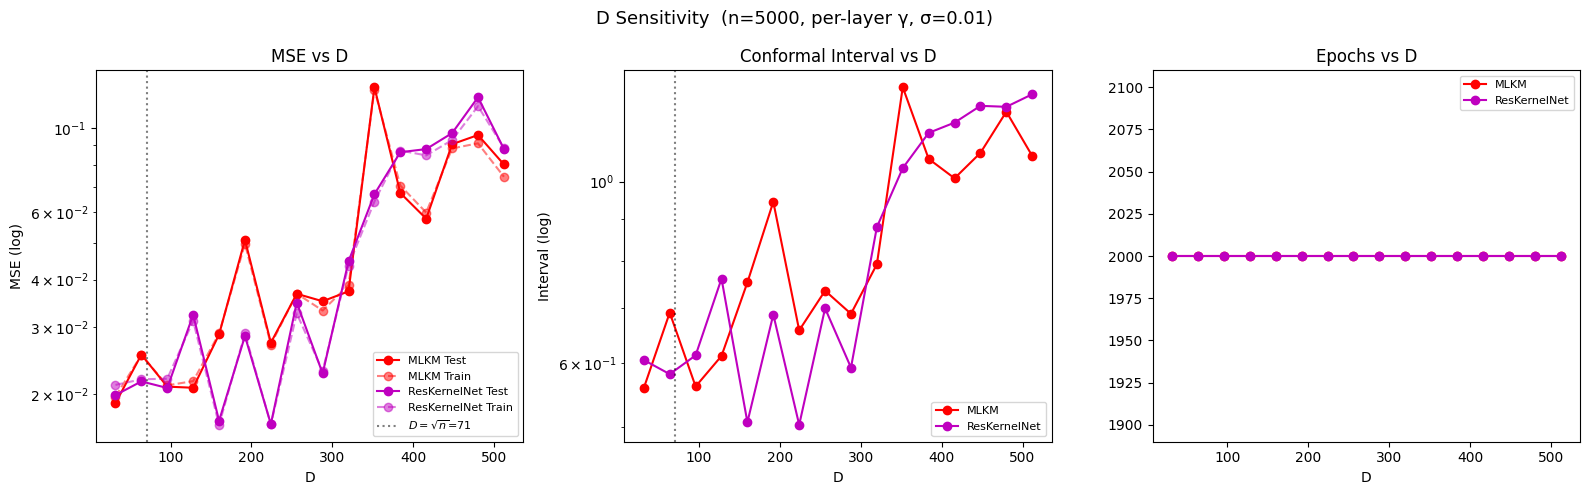

Best D for MLKM: 32  |  ResKernelNet: 224  |  sqrt(n)=70


In [ ]:
# # ── Section 3: D sweep  σ=0.01 ───────────────────────────────────────────────
# D_results = []
# for D in tqdm(D_VALUES, desc='D sweep σ=0.01'):
#     row = {'D': D}
#     _g1_D, _g2_D = _compute_per_layer_gammas(X_tr, D=D)
#     for label, make_net in [
#         ('MLKM',         lambda D=D, g=(_g1_D, _g2_D): KernelNet(D=D, gammas=g)),
#         ('ResKernelNet', lambda D=D, g=(_g1_D, _g2_D): ResKernelNet(D1=D, gammas=g)),
#     ]:
#         set_seed(SEED)
#         net = make_net(); net.apply(init_weights)
#         net, opt, trl, tel = train_model(net, X_tr, y_tr, X_te, y_te, verbose=False)
#         cov, lng, q = conformal_split(net, X_cal, y_cal, X_te, y_te)
#         row[f'{label}_train'] = trl[-1]
#         row[f'{label}_test']  = tel[-1]
#         row[f'{label}_interval'] = lng
#         row[f'{label}_ep'] = len(trl)
#     D_results.append(row)

# D_df = pd.DataFrame(D_results)
# print(D_df.round(4).to_string(index=False))

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# for label, c in [('MLKM','r'), ('ResKernelNet','m')]:
#     axes[0].plot(D_df['D'], D_df[f'{label}_test'],     marker='o', ls='-',  color=c, label=f'{label} Test')
#     axes[0].plot(D_df['D'], D_df[f'{label}_train'],    marker='o', ls='--', color=c, label=f'{label} Train', alpha=0.5)
#     axes[1].plot(D_df['D'], D_df[f'{label}_interval'], marker='o', ls='-',  color=c, label=label)
#     axes[2].plot(D_df['D'], D_df[f'{label}_ep'],       marker='o', ls='-',  color=c, label=label)
# axes[0].axvline(71, color='k', ls=':', alpha=0.5, label=r'$D=\sqrt{n}$=71')
# axes[1].axvline(71, color='k', ls=':', alpha=0.5)
# axes[0].set_title('MSE vs D'); axes[1].set_title('Conformal Interval vs D'); axes[2].set_title('Epochs vs D')
# for ax in axes[:2]: ax.set_xlabel('D'); ax.set_yscale('log'); ax.legend(fontsize=8)
# axes[2].set_xlabel('D'); axes[2].legend(fontsize=8)
# axes[0].set_ylabel('MSE (log)'); axes[1].set_ylabel('Interval (log)')
# plt.suptitle('D Sensitivity  (n=5000, per-layer γ, σ=0.01)', fontsize=13)
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, 'sec3_D_sensitivity_sigma001.png'), dpi=120, bbox_inches='tight')
# plt.show()
# D_df.to_csv(os.path.join(RESULTS_DIR, 'sec3_D_sensitivity_sigma001_results.csv'), index=False)
# best_D_mlkm = int(D_df.loc[D_df['MLKM_test'].idxmin(), 'D'])
# best_D_rkm  = int(D_df.loc[D_df['ResKernelNet_test'].idxmin(), 'D'])
# print(f'Best D for MLKM: {best_D_mlkm}  |  ResKernelNet: {best_D_rkm}  |  sqrt(n)={int(np.sqrt(n_base))}')

D sweep σ=0.1: 100%|██████████| 16/16 [5:07:59<00:00, 1154.97s/it]  


  D  MLKM_train  MLKM_test  MLKM_interval  MLKM_ep  ResKernelNet_train  ResKernelNet_test  ResKernelNet_interval  ResKernelNet_ep
 32      0.0307     0.0305         0.6756     2000              0.0293             0.0296                 0.6745             2000
 64      0.0343     0.0345         0.7106     2000              0.0320             0.0323                 0.6652             2000
 96      0.0328     0.0343         0.6899     2000              0.0304             0.0304                 0.6718             2000
128      0.0292     0.0300         0.6711     2000              0.0325             0.0335                 0.7118             2000
160      0.0500     0.0503         0.9239     2000              0.0307             0.0310                 0.6563             2000
192      0.0785     0.0767         1.1725     2000              0.0501             0.0514                 0.8335             2000
224      0.0470     0.0475         0.8681     2000              0.0408             0.0417 

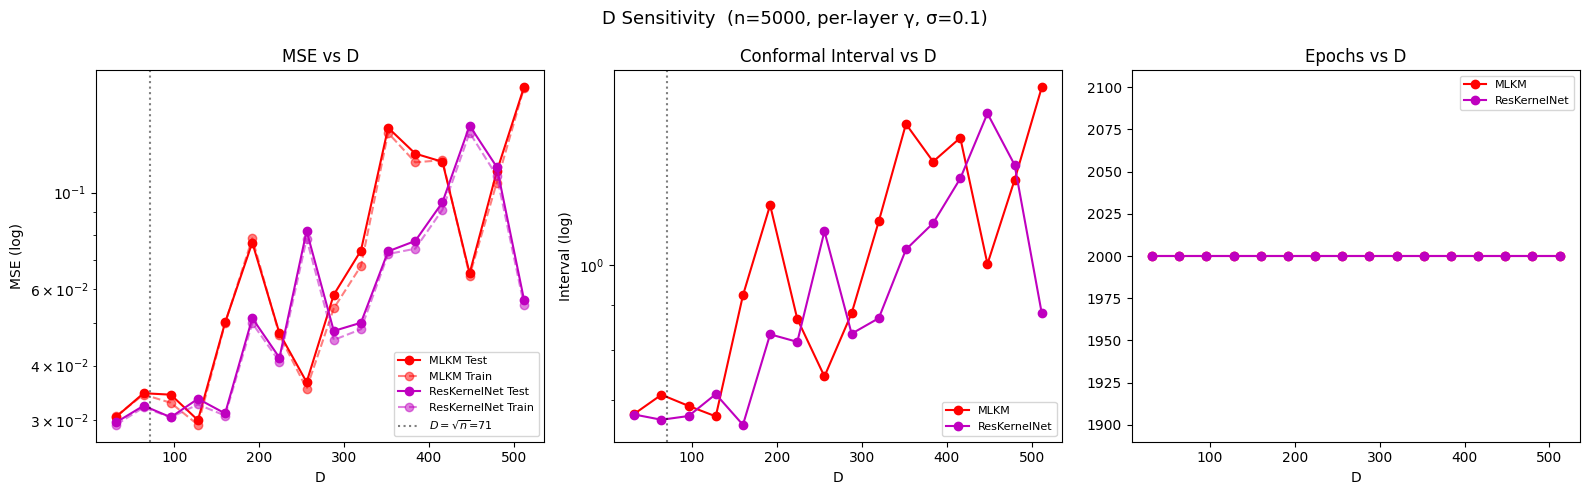

Best D for MLKM (σ=0.1): 128  |  ResKernelNet: 32


In [ ]:
# # ── Section 3: D sweep  σ=0.1 ────────────────────────────────────────────────
# D_results_01 = []
# for D in tqdm(D_VALUES, desc='D sweep σ=0.1'):
#     row = {'D': D}
#     _g1_D01, _g2_D01 = _compute_per_layer_gammas(X_tr1, D=D)
#     for label, make_net in [
#         ('MLKM',         lambda D=D, g=(_g1_D01, _g2_D01): KernelNet(D=D, gammas=g)),
#         ('ResKernelNet', lambda D=D, g=(_g1_D01, _g2_D01): ResKernelNet(D1=D, gammas=g)),
#     ]:
#         set_seed(SEED)
#         net = make_net(); net.apply(init_weights)
#         net, opt, trl, tel = train_model(net, X_tr1, y_tr1, X_te1, y_te1, verbose=False)
#         cov, lng, q = conformal_split(net, X_cal1, y_cal1, X_te1, y_te1)
#         row[f'{label}_train'] = trl[-1]
#         row[f'{label}_test']  = tel[-1]
#         row[f'{label}_interval'] = lng
#         row[f'{label}_ep'] = len(trl)
#     D_results_01.append(row)

# D_df_01 = pd.DataFrame(D_results_01)
# print(D_df_01.round(4).to_string(index=False))

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# for label, c in [('MLKM','r'), ('ResKernelNet','m')]:
#     axes[0].plot(D_df_01['D'], D_df_01[f'{label}_test'],     marker='o', ls='-',  color=c, label=f'{label} Test')
#     axes[0].plot(D_df_01['D'], D_df_01[f'{label}_train'],    marker='o', ls='--', color=c, label=f'{label} Train', alpha=0.5)
#     axes[1].plot(D_df_01['D'], D_df_01[f'{label}_interval'], marker='o', ls='-',  color=c, label=label)
#     axes[2].plot(D_df_01['D'], D_df_01[f'{label}_ep'],       marker='o', ls='-',  color=c, label=label)
# axes[0].axvline(71, color='k', ls=':', alpha=0.5, label=r'$D=\sqrt{n}$=71')
# axes[1].axvline(71, color='k', ls=':', alpha=0.5)
# axes[0].set_title('MSE vs D'); axes[1].set_title('Conformal Interval vs D'); axes[2].set_title('Epochs vs D')
# for ax in axes[:2]: ax.set_xlabel('D'); ax.set_yscale('log'); ax.legend(fontsize=8)
# axes[2].set_xlabel('D'); axes[2].legend(fontsize=8)
# axes[0].set_ylabel('MSE (log)'); axes[1].set_ylabel('Interval (log)')
# plt.suptitle('D Sensitivity  (n=5000, per-layer γ, σ=0.1)', fontsize=13)
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, 'sec3_D_sensitivity_sigma01.png'), dpi=120, bbox_inches='tight')
# plt.show()
# D_df_01.to_csv(os.path.join(RESULTS_DIR, 'sec3_D_sensitivity_sigma01_results.csv'), index=False)
# best_D_mlkm_01 = int(D_df_01.loc[D_df_01['MLKM_test'].idxmin(), 'D'])
# best_D_rkm_01  = int(D_df_01.loc[D_df_01['ResKernelNet_test'].idxmin(), 'D'])
# print(f'Best D for MLKM (σ=0.1): {best_D_mlkm_01}  |  ResKernelNet: {best_D_rkm_01}')

## Section 3b: Joint (n, D) Sensitivity

Full grid over $(n, D)$ pairs to understand how optimal $D$ scales with $n$.
Runs for both per-layer gamma (Layer Gamma) and fixed gamma (GAMMA_DEF).

## Layer Gamma - D Sensitivity Analysis

In [ ]:
# # ── Layer Gamma: Joint (n, D) grid  σ=0.01 ───────────────────────────────────
# # Shared cal/test from Section 2 (seed 999)
# _rng_sh = np.random.RandomState(999)
# X_cal_sh = _rng_sh.uniform(-6, 6, (1000, 2)).astype('float32')
# y_cal_sh = f_star(X_cal_sh) + (0.01 * _rng_sh.randn(1000)).astype('float32')
# X_te_sh  = _rng_sh.uniform(-6, 6, (2000, 2)).astype('float32')
# y_te_sh  = f_star(X_te_sh)  + (0.01 * _rng_sh.randn(2000)).astype('float32')

# _N_GRID = [200, 500, 1000, 2000, 4000, 6000, 8000]
# _D_grid = list(range(32, 513, 32))
# nD_rows_01 = []
# for n in tqdm(_N_GRID, desc='n loop layer-γ σ=0.01'):
#     rng_n = np.random.RandomState(n)
#     X_n = rng_n.uniform(-6, 6, (n, 2)).astype('float32')
#     y_n = f_star(X_n) + (0.01 * rng_n.randn(n)).astype('float32')
#     for D in _D_grid:
#         _g1_nD, _g2_nD = _compute_per_layer_gammas(X_n, D=D)
#         set_seed(SEED)
#         net = KernelNet(D=D, gammas=(_g1_nD, _g2_nD)); net.apply(init_weights)
#         net, opt, trl, tel = train_model(net, X_n, y_n, X_te_sh, y_te_sh, verbose=False)
#         cov, lng, _ = conformal_split(net, X_cal_sh, y_cal_sh, X_te_sh, y_te_sh)
#         nD_rows_01.append({'n': n, 'D': D, 'test_mse': tel[-1], 'interval': lng})
#         print(f'  n={n:5d}  D={D:4d}: test={tel[-1]:.5f}  interval={lng:.4f}')

# nD_df_01 = pd.DataFrame(nD_rows_01)
# mse_pivot_01 = nD_df_01.pivot(index='n', columns='D', values='test_mse')
# int_pivot_01 = nD_df_01.pivot(index='n', columns='D', values='interval')
# nD_df_01.to_csv(os.path.join(RESULTS_DIR, 'sec3b_layer_gamma_nD_sigma001.csv'), index=False)
# print(mse_pivot_01.round(5).to_string())

n loop layer-γ σ=0.01:   0%|          | 0/7 [00:00<?, ?it/s]

  n=  200  D=  32: test=0.22885  interval=2.0251
  n=  200  D=  64: test=0.22240  interval=1.9912
  n=  200  D=  96: test=0.22380  interval=2.0813
  n=  200  D= 128: test=0.21569  interval=1.9510
  n=  200  D= 160: test=0.20710  interval=1.8494
  n=  200  D= 192: test=0.22124  interval=1.9065
  n=  200  D= 224: test=0.18756  interval=1.7160
  n=  200  D= 256: test=0.18635  interval=1.7299
  n=  200  D= 288: test=0.20096  interval=1.8089
  n=  200  D= 320: test=0.19279  interval=1.7838
  n=  200  D= 352: test=0.18315  interval=1.7252
  n=  200  D= 384: test=0.17351  interval=1.6612
  n=  200  D= 416: test=0.19099  interval=1.7435
  n=  200  D= 448: test=0.18895  interval=1.7091
  n=  200  D= 480: test=0.18929  interval=1.7150


n loop layer-γ σ=0.01:  14%|█▍        | 1/7 [17:25<1:44:30, 1045.12s/it]

  n=  200  D= 512: test=0.17864  interval=1.6888
  n=  500  D=  32: test=0.19742  interval=1.7533
  n=  500  D=  64: test=0.17731  interval=1.7415
  n=  500  D=  96: test=0.15128  interval=1.5760
  n=  500  D= 128: test=0.16208  interval=1.6426
  n=  500  D= 160: test=0.16541  interval=1.6619
  n=  500  D= 192: test=0.17545  interval=1.6981
  n=  500  D= 224: test=0.14953  interval=1.5087
  n=  500  D= 256: test=0.16204  interval=1.6039
  n=  500  D= 288: test=0.16795  interval=1.6407
  n=  500  D= 320: test=0.17986  interval=1.7708
  n=  500  D= 352: test=0.18930  interval=1.7854
  n=  500  D= 384: test=0.17028  interval=1.6708
  n=  500  D= 416: test=0.16488  interval=1.6987
  n=  500  D= 448: test=0.16831  interval=1.7237
  n=  500  D= 480: test=0.18066  interval=1.6599


n loop layer-γ σ=0.01:  29%|██▊       | 2/7 [19:27<41:53, 502.60s/it]   

...

  n= 4000  D= 512: test=0.16721  interval=1.6027
  n= 6000  D=  32: test=0.15106  interval=1.6668
  n= 6000  D=  64: test=0.15869  interval=1.6915
  n= 6000  D=  96: test=0.14790  interval=1.6767
  n= 6000  D= 128: test=0.14459  interval=1.6764
  n= 6000  D= 160: test=0.14447  interval=1.5664
  n= 6000  D= 192: test=0.14900  interval=1.6050
  n= 6000  D= 224: test=0.15525  interval=1.6798
  n= 6000  D= 256: test=0.16455  interval=1.5331
  n= 6000  D= 288: test=0.13833  interval=1.5308
  n= 6000  D= 320: test=0.14863  interval=1.5674
  n= 6000  D= 352: test=0.17802  interval=1.7170
  n= 6000  D= 384: test=0.16354  interval=1.6219
  n= 6000  D= 416: test=0.15002  interval=1.5057
  n= 6000  D= 448: test=0.14348  interval=1.4495
  n= 6000  D= 480: test=0.15085  interval=1.5908


n loop layer-γ σ=0.01:  86%|████████▌ | 6/7 [3:38:54<41:02, 2462.63s/it]  

  n= 6000  D= 512: test=0.15175  interval=1.5910
  n= 8000  D=  32: test=0.15281  interval=1.6834
  n= 8000  D=  64: test=0.15614  interval=1.7260
  n= 8000  D=  96: test=0.11379  interval=1.4994
  n= 8000  D= 128: test=0.13943  interval=1.5291
  n= 8000  D= 160: test=0.14238  interval=1.5812
  n= 8000  D= 192: test=0.12275  interval=1.4831
  n= 8000  D= 224: test=0.14082  interval=1.5030
  n= 8000  D= 256: test=0.15341  interval=1.5014
  n= 8000  D= 288: test=0.14227  interval=1.4835
  n= 8000  D= 320: test=0.14000  interval=1.5922
  n= 8000  D= 352: test=0.17169  interval=1.7036
  n= 8000  D= 384: test=0.17182  interval=1.7103
  n= 8000  D= 416: test=0.16052  interval=1.6848
  n= 8000  D= 448: test=0.14456  interval=1.5695
  n= 8000  D= 480: test=0.16211  interval=1.6043


n loop layer-γ σ=0.01: 100%|██████████| 7/7 [4:10:47<00:00, 2149.62s/it]

  n= 8000  D= 512: test=0.16210  interval=1.6730
D         32       64       96       128      160      192      224      256      288      320      352      384      416      448      480      512
n                                                                                                                                                   
200   0.22885  0.22240  0.22380  0.21569  0.20710  0.22124  0.18756  0.18635  0.20096  0.19279  0.18315  0.17351  0.19099  0.18895  0.18929  0.17864
500   0.19742  0.17731  0.15128  0.16208  0.16541  0.17545  0.14953  0.16204  0.16795  0.17986  0.18930  0.17028  0.16488  0.16831  0.18066  0.17326
1000  0.19134  0.16302  0.15145  0.16380  0.18921  0.15105  0.16038  0.16399  0.18558  0.18315  0.17920  0.16518  0.16128  0.17029  0.16917  0.15491
2000  0.15763  0.15388  0.12554  0.12344  0.13297  0.16386  0.16198  0.15597  0.14636  0.16470  0.17665  0.15823  0.19171  0.16266  0.17486  0.16588
4000  0.14990  0.15457  0.14643  0.15462  0.13603  0.1740

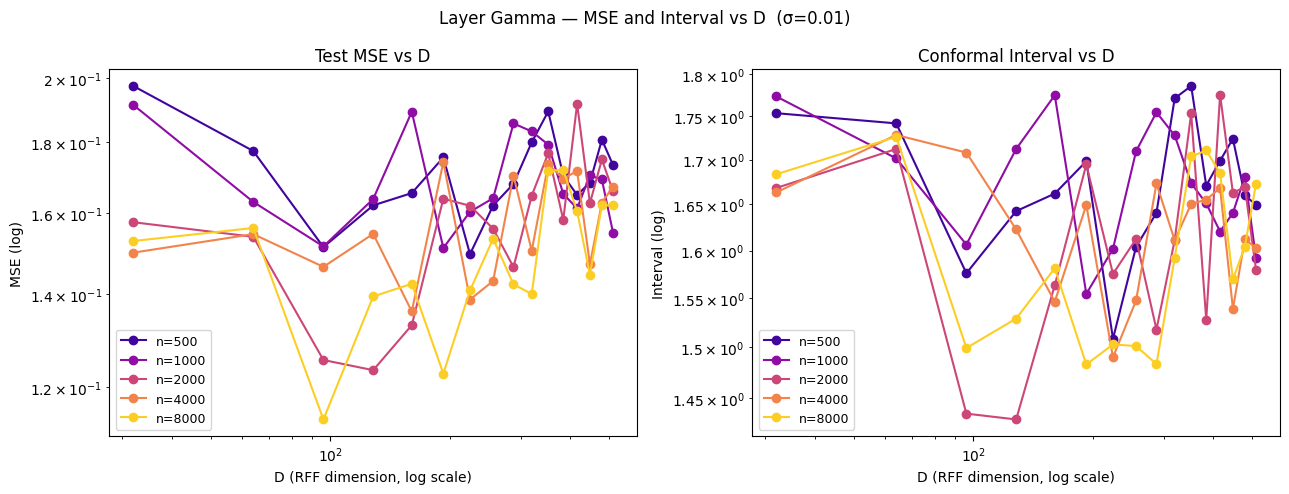

In [ ]:
# plot_ns = [n for n in _N_GRID if n not in [200, 6000]]
# palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(plot_ns)))
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# for i, n in enumerate(plot_ns):
#     sub = nD_df_01[nD_df_01['n'] == n]
#     axes[0].plot(sub['D'], sub['test_mse'], marker='o', color=palette[i], label=f'n={n}')
#     axes[1].plot(sub['D'], sub['interval'], marker='o', color=palette[i], label=f'n={n}')
# for ax in axes:
#     ax.set_xscale('log'); ax.set_yscale('log')
#     ax.set_xlabel('D (RFF dimension, log scale)'); ax.legend(fontsize=9)
# axes[0].set_title('Test MSE vs D'); axes[0].set_ylabel('MSE (log)')
# axes[1].set_title('Conformal Interval vs D'); axes[1].set_ylabel('Interval (log)')
# plt.suptitle('Layer Gamma — MSE and Interval vs D  (σ=0.01)', fontsize=12)
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, 'sec3b_layer_gamma_nD_plot_sigma001.png'), dpi=120, bbox_inches='tight')
# plt.show()

In [ ]:
# summary_rows = []; raw_Ds = []
# for n, row in mse_pivot_01.iterrows():
#     row = row.sort_index()
#     best_mse = row.min(); base_mse = row.loc[32]
#     thresh = best_mse + 0.05 * (base_mse - best_mse)
#     near_best_D = row[row <= thresh].index.min()
#     raw_Ds.append(int(near_best_D))
#     summary_rows.append({'n': int(n), 'best_mse': float(best_mse),
#                          'baseline_mse_D32': float(base_mse), 'raw_near_best_D': int(near_best_D)})
# summary_df = pd.DataFrame(summary_rows).sort_values('n')
# summary_df['recommended_D_monotone'] = np.maximum.accumulate(summary_df['raw_near_best_D'].values)
# print('Layer Gamma σ=0.01 — Near-best D:')
# print(summary_df.to_string(index=False))

Layer Gamma σ=0.01 — Near-best D:
   n  best_mse  baseline_mse_D32  raw_near_best_D  recommended_D_monotone
 200  0.173506          0.228845              384                     384
 500  0.149527          0.197424               96                     384
1000  0.151055          0.191335               96                     384
2000  0.123442          0.157631              128                     384
4000  0.136027          0.149903              160                     384
6000  0.138330          0.151064              288                     384
8000  0.113790          0.152813               96                     384


In [ ]:
# # ── Layer Gamma: Joint (n, D) grid  σ=0.1 ────────────────────────────────────
# _rng_sh1 = np.random.RandomState(999)
# X_cal_sh1 = _rng_sh1.uniform(-6, 6, (1000, 2)).astype('float32')
# y_cal_sh1 = f_star(X_cal_sh1) + (0.1 * _rng_sh1.randn(1000)).astype('float32')
# X_te_sh1  = _rng_sh1.uniform(-6, 6, (2000, 2)).astype('float32')
# y_te_sh1  = f_star(X_te_sh1)  + (0.1 * _rng_sh1.randn(2000)).astype('float32')

# _D_grid_1 = list(range(32, 513, 32))
# nD_rows_1 = []
# for n in tqdm(_N_GRID, desc='n loop layer-γ σ=0.1'):
#     rng_n = np.random.RandomState(n)
#     X_n = rng_n.uniform(-6, 6, (n, 2)).astype('float32')
#     y_n = f_star(X_n) + (0.1 * rng_n.randn(n)).astype('float32')
#     for D in _D_grid_1:
#         _g1_nD, _g2_nD = _compute_per_layer_gammas(X_n, D=D)
#         set_seed(SEED)
#         net = KernelNet(D=D, gammas=(_g1_nD, _g2_nD)); net.apply(init_weights)
#         net, opt, trl, tel = train_model(net, X_n, y_n, X_te_sh1, y_te_sh1, verbose=False)
#         cov, lng, _ = conformal_split(net, X_cal_sh1, y_cal_sh1, X_te_sh1, y_te_sh1)
#         nD_rows_1.append({'n': n, 'D': D, 'test_mse': tel[-1], 'interval': lng})
#         print(f'  n={n:5d}  D={D:4d}: test={tel[-1]:.5f}  interval={lng:.4f}')

# nD_df_1 = pd.DataFrame(nD_rows_1)
# mse_pivot_1 = nD_df_1.pivot(index='n', columns='D', values='test_mse')
# int_pivot_1 = nD_df_1.pivot(index='n', columns='D', values='interval')
# nD_df_1.to_csv(os.path.join(RESULTS_DIR, 'sec3b_layer_gamma_nD_sigma01.csv'), index=False)
# print(mse_pivot_1.round(5).to_string())

n loop layer-γ σ=0.1:   0%|          | 0/7 [00:00<?, ?it/s]

  n=  200  D=  32: test=0.22624  interval=2.0524
  n=  200  D=  64: test=0.21833  interval=1.9656
  n=  200  D=  96: test=0.21977  interval=2.0149
  n=  200  D= 128: test=0.24224  interval=2.1820
  n=  200  D= 160: test=0.19820  interval=1.7981
  n=  200  D= 192: test=0.20265  interval=1.8475
  n=  200  D= 224: test=0.19393  interval=1.7931
  n=  200  D= 256: test=0.22416  interval=1.9604
  n=  200  D= 288: test=0.20876  interval=1.8354
  n=  200  D= 320: test=0.19077  interval=1.8117
  n=  200  D= 352: test=0.19340  interval=1.7923
  n=  200  D= 384: test=0.19807  interval=1.8393
  n=  200  D= 416: test=0.18670  interval=1.7617
  n=  200  D= 448: test=0.19711  interval=1.7963
  n=  200  D= 480: test=0.19937  interval=1.7583


n loop layer-γ σ=0.1:  14%|█▍        | 1/7 [01:47<10:47, 107.92s/it]

  n=  200  D= 512: test=0.19110  interval=1.7871
  n=  500  D=  32: test=0.20514  interval=1.8236
  n=  500  D=  64: test=0.18403  interval=1.7902
  n=  500  D=  96: test=0.15661  interval=1.7035
  n=  500  D= 128: test=0.17595  interval=1.7818
  n=  500  D= 160: test=0.21792  interval=1.8900
  n=  500  D= 192: test=0.18748  interval=1.7713
  n=  500  D= 224: test=0.16867  interval=1.7230
  n=  500  D= 256: test=0.17230  interval=1.6877
  n=  500  D= 288: test=0.18672  interval=1.7188
  n=  500  D= 320: test=0.17624  interval=1.7205
  n=  500  D= 352: test=0.18871  interval=1.7502
  n=  500  D= 384: test=0.18014  interval=1.6823
  n=  500  D= 416: test=0.18861  interval=1.7841
  n=  500  D= 448: test=0.17168  interval=1.6935
  n=  500  D= 480: test=0.18684  interval=1.7329


n loop layer-γ σ=0.1:  29%|██▊       | 2/7 [04:46<12:26, 149.24s/it]

...

  n= 4000  D= 512: test=0.17233  interval=1.7193
  n= 6000  D=  32: test=0.15480  interval=1.6444
  n= 6000  D=  64: test=0.16390  interval=1.7471
  n= 6000  D=  96: test=0.14627  interval=1.7079
  n= 6000  D= 128: test=0.14765  interval=1.7223
  n= 6000  D= 160: test=0.14708  interval=1.5873
  n= 6000  D= 192: test=0.13551  interval=1.5543
  n= 6000  D= 224: test=0.14032  interval=1.5905
  n= 6000  D= 256: test=0.14521  interval=1.5715
  n= 6000  D= 288: test=0.14329  interval=1.5165
  n= 6000  D= 320: test=0.15380  interval=1.6267
  n= 6000  D= 352: test=0.16905  interval=1.7326
  n= 6000  D= 384: test=0.16777  interval=1.7113
  n= 6000  D= 416: test=0.17933  interval=1.6925
  n= 6000  D= 448: test=0.14938  interval=1.5682
  n= 6000  D= 480: test=0.18145  interval=1.7545


n loop layer-γ σ=0.1:  86%|████████▌ | 6/7 [46:25<11:02, 662.09s/it]

  n= 6000  D= 512: test=0.17708  interval=1.7536
  n= 8000  D=  32: test=0.15421  interval=1.7068
  n= 8000  D=  64: test=0.16587  interval=1.7825
  n= 8000  D=  96: test=0.12594  interval=1.5299
  n= 8000  D= 128: test=0.15370  interval=1.7205
  n= 8000  D= 160: test=0.14984  interval=1.5853
  n= 8000  D= 192: test=0.14095  interval=1.5412
  n= 8000  D= 224: test=0.14372  interval=1.6065
  n= 8000  D= 256: test=0.14338  interval=1.6022
  n= 8000  D= 288: test=0.17245  interval=1.6963
  n= 8000  D= 320: test=0.17289  interval=1.7416
  n= 8000  D= 352: test=0.18695  interval=1.8006
  n= 8000  D= 384: test=0.17383  interval=1.6813
  n= 8000  D= 416: test=0.17931  interval=1.7060
  n= 8000  D= 448: test=0.16023  interval=1.6390
  n= 8000  D= 480: test=0.17417  interval=1.7755


n loop layer-γ σ=0.1: 100%|██████████| 7/7 [1:10:05<00:00, 600.73s/it]

  n= 8000  D= 512: test=0.18101  interval=1.7390
D         32       64       96       128      160      192      224      256      288      320      352      384      416      448      480      512
n                                                                                                                                                   
200   0.22624  0.21833  0.21977  0.24224  0.19820  0.20265  0.19393  0.22416  0.20876  0.19077  0.19340  0.19807  0.18670  0.19711  0.19937  0.19110
500   0.20514  0.18403  0.15661  0.17595  0.21792  0.18748  0.16867  0.17230  0.18672  0.17624  0.18871  0.18014  0.18861  0.17168  0.18684  0.20637
1000  0.19467  0.15924  0.11888  0.15286  0.18054  0.17572  0.16245  0.15322  0.17146  0.18368  0.16840  0.19072  0.17212  0.16212  0.18279  0.17984
2000  0.15991  0.16268  0.11791  0.16748  0.14898  0.12909  0.17251  0.15135  0.17608  0.17928  0.18138  0.17474  0.18887  0.16386  0.18545  0.17829
4000  0.15987  0.13027  0.13659  0.15520  0.17682  0.1258

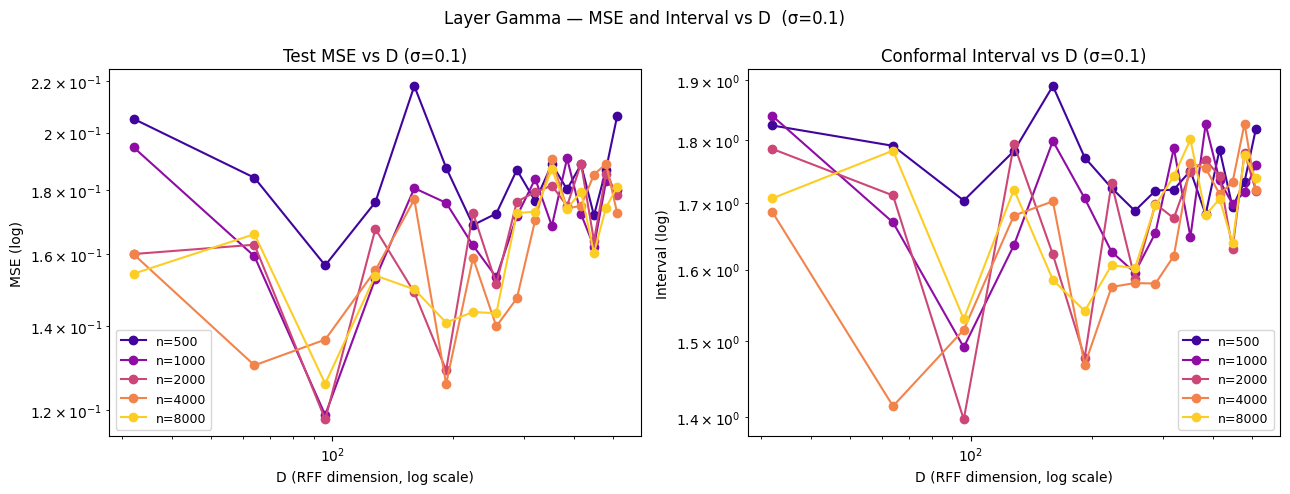

In [ ]:
# plot_ns = [n for n in _N_GRID if n not in [200, 6000]]
# palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(plot_ns)))
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# for i, n in enumerate(plot_ns):
#     sub = nD_df_1[nD_df_1['n'] == n]
#     axes[0].plot(sub['D'], sub['test_mse'], marker='o', color=palette[i], label=f'n={n}')
#     axes[1].plot(sub['D'], sub['interval'], marker='o', color=palette[i], label=f'n={n}')
# for ax in axes:
#     ax.set_xscale('log'); ax.set_yscale('log')
#     ax.set_xlabel('D (RFF dimension, log scale)'); ax.legend(fontsize=9)
# axes[0].set_title('Test MSE vs D (σ=0.1)'); axes[0].set_ylabel('MSE (log)')
# axes[1].set_title('Conformal Interval vs D (σ=0.1)'); axes[1].set_ylabel('Interval (log)')
# plt.suptitle('Layer Gamma — MSE and Interval vs D  (σ=0.1)', fontsize=12)
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, 'sec3b_layer_gamma_nD_plot_sigma01.png'), dpi=120, bbox_inches='tight')
# plt.show()

In [ ]:
# summary_rows_1 = []; raw_Ds_1 = []
# for n, row in mse_pivot_1.iterrows():
#     row = row.sort_index()
#     best_mse = row.min(); base_mse = row.loc[32]
#     thresh = best_mse + 0.05 * (base_mse - best_mse)
#     near_best_D = row[row <= thresh].index.min()
#     raw_Ds_1.append(int(near_best_D))
#     summary_rows_1.append({'n': int(n), 'best_mse': float(best_mse),
#                            'baseline_mse_D32': float(base_mse), 'raw_near_best_D': int(near_best_D)})
# summary_df_1 = pd.DataFrame(summary_rows_1).sort_values('n')
# summary_df_1['recommended_D_monotone'] = np.maximum.accumulate(summary_df_1['raw_near_best_D'].values)
# print('Layer Gamma σ=0.1 — Near-best D:')
# print(summary_df_1.to_string(index=False))

Layer Gamma σ=0.1 — Near-best D:
   n  best_mse  baseline_mse_D32  raw_near_best_D  recommended_D_monotone
 200  0.186701          0.226245              416                     416
 500  0.156611          0.205143               96                     416
1000  0.118877          0.194668               96                     416
2000  0.117908          0.159910               96                     416
4000  0.125870          0.159872              192                     416
6000  0.135511          0.154797              192                     416
8000  0.125945          0.154212               96                     416


## Fixed Gamma - D Sensitivity Analysis

In [63]:
# ── Fixed Gamma: Joint (n, D) grid  σ=0.01 ──────────────────────────────────
_D_grid_fg = list(range(32, 513, 32))
nD_rows_fg_01 = []
for n in tqdm(_N_GRID, desc='n loop fixed-γ σ=0.01'):
    rng_n = np.random.RandomState(n)
    X_n = rng_n.uniform(-6, 6, (n, 2)).astype('float32')
    y_n = f_star(X_n) + (0.01 * rng_n.randn(n)).astype('float32')
    for D in _D_grid_fg:
        set_seed(SEED)
        net = KernelNet(D=D, gamma=GAMMA_DEF); net.apply(init_weights)
        net, opt, trl, tel = train_model(net, X_n, y_n, X_te_sh, y_te_sh, verbose=False)
        cov, lng, _ = conformal_split(net, X_cal_sh, y_cal_sh, X_te_sh, y_te_sh)
        nD_rows_fg_01.append({'n': n, 'D': D, 'test_mse': tel[-1], 'interval': lng})
        print(f'  n={n:5d}  D={D:4d}: test={tel[-1]:.5f}  interval={lng:.4f}')

D_df_fg_01 = pd.DataFrame(nD_rows_fg_01)
mse_pivot_fg_01 = D_df_fg_01.pivot(index='n', columns='D', values='test_mse')
int_pivot_fg_01 = D_df_fg_01.pivot(index='n', columns='D', values='interval')
D_df_fg_01.to_csv(os.path.join(RESULTS_DIR, 'sec3b_fixed_gamma_nD_sigma001.csv'), index=False)
print(mse_pivot_fg_01.round(5).to_string())

n loop fixed-γ σ=0.01:   0%|          | 0/7 [00:00<?, ?it/s]

  n=  200  D=  32: test=0.20717  interval=1.8213
  n=  200  D=  64: test=0.20216  interval=1.8313
  n=  200  D=  96: test=0.19794  interval=1.7829
  n=  200  D= 128: test=0.19974  interval=1.7733
  n=  200  D= 160: test=0.20057  interval=1.7679
  n=  200  D= 192: test=0.20418  interval=1.8175
  n=  200  D= 224: test=0.20386  interval=1.8274
  n=  200  D= 256: test=0.21075  interval=1.8578
  n=  200  D= 288: test=0.20585  interval=1.8440
  n=  200  D= 320: test=0.21109  interval=1.9039
  n=  200  D= 352: test=0.21319  interval=1.9879
  n=  200  D= 384: test=0.21070  interval=1.9490
  n=  200  D= 416: test=0.20897  interval=1.8760
  n=  200  D= 448: test=0.21199  interval=1.9084
  n=  200  D= 480: test=0.21062  interval=1.9335


n loop fixed-γ σ=0.01:  14%|█▍        | 1/7 [01:11<07:11, 71.98s/it]

  n=  200  D= 512: test=0.21198  interval=1.9444
  n=  500  D=  32: test=0.18748  interval=1.7315
  n=  500  D=  64: test=0.18992  interval=1.7506
  n=  500  D=  96: test=0.19432  interval=1.7390
  n=  500  D= 128: test=0.19316  interval=1.7463
  n=  500  D= 160: test=0.19763  interval=1.8096
  n=  500  D= 192: test=0.19424  interval=1.7162
  n=  500  D= 224: test=0.19462  interval=1.7527
  n=  500  D= 256: test=0.19068  interval=1.7114
  n=  500  D= 288: test=0.19395  interval=1.7720
  n=  500  D= 320: test=0.19765  interval=1.7877
  n=  500  D= 352: test=0.19150  interval=1.7261
  n=  500  D= 384: test=0.20113  interval=1.7744
  n=  500  D= 416: test=0.19740  interval=1.7870
  n=  500  D= 448: test=0.19204  interval=1.7407
  n=  500  D= 480: test=0.19346  interval=1.7285


n loop fixed-γ σ=0.01:  29%|██▊       | 2/7 [03:12<08:23, 100.78s/it]

...

  n= 4000  D= 512: test=0.14846  interval=1.6303
  n= 6000  D=  32: test=0.16644  interval=1.6178
  n= 6000  D=  64: test=0.12278  interval=1.4359
  n= 6000  D=  96: test=0.13236  interval=1.5769
  n= 6000  D= 128: test=0.15550  interval=1.6753
  n= 6000  D= 160: test=0.11323  interval=1.4811
  n= 6000  D= 192: test=0.11819  interval=1.4398
  n= 6000  D= 224: test=0.12059  interval=1.4991
  n= 6000  D= 256: test=0.12756  interval=1.4715
  n= 6000  D= 288: test=0.10544  interval=1.4524
  n= 6000  D= 320: test=0.13734  interval=1.5095
  n= 6000  D= 352: test=0.15802  interval=1.6887
  n= 6000  D= 384: test=0.15615  interval=1.7115
  n= 6000  D= 416: test=0.15903  interval=1.6709
  n= 6000  D= 448: test=0.15530  interval=1.6709
  n= 6000  D= 480: test=0.16026  interval=1.6760


n loop fixed-γ σ=0.01:  86%|████████▌ | 6/7 [45:51<11:36, 696.97s/it]

  n= 6000  D= 512: test=0.11188  interval=1.4699
  n= 8000  D=  32: test=0.15790  interval=1.6438
  n= 8000  D=  64: test=0.13991  interval=1.6017
  n= 8000  D=  96: test=0.11939  interval=1.4636
  n= 8000  D= 128: test=0.11439  interval=1.4587
  n= 8000  D= 160: test=0.10921  interval=1.4486
  n= 8000  D= 192: test=0.11114  interval=1.4539
  n= 8000  D= 224: test=0.11066  interval=1.4516
  n= 8000  D= 256: test=0.12336  interval=1.4496
  n= 8000  D= 288: test=0.10801  interval=1.5116
  n= 8000  D= 320: test=0.14972  interval=1.6904
  n= 8000  D= 352: test=0.15612  interval=1.7174
  n= 8000  D= 384: test=0.11594  interval=1.4711
  n= 8000  D= 416: test=0.15325  interval=1.6850
  n= 8000  D= 448: test=0.15691  interval=1.6762
  n= 8000  D= 480: test=0.15754  interval=1.7399


n loop fixed-γ σ=0.01: 100%|██████████| 7/7 [3:30:44<00:00, 1806.38s/it]

  n= 8000  D= 512: test=0.12201  interval=1.4941
D         32       64       96       128      160      192      224      256      288      320      352      384      416      448      480      512
n                                                                                                                                                   
200   0.20717  0.20216  0.19794  0.19974  0.20057  0.20418  0.20386  0.21075  0.20585  0.21109  0.21319  0.21070  0.20897  0.21199  0.21062  0.21198
500   0.18748  0.18992  0.19432  0.19316  0.19763  0.19424  0.19462  0.19068  0.19395  0.19765  0.19150  0.20113  0.19740  0.19204  0.19346  0.19569
1000  0.19046  0.18855  0.18881  0.18646  0.17748  0.18996  0.18453  0.18400  0.18563  0.17857  0.18081  0.17534  0.18463  0.18626  0.18864  0.18544
2000  0.17663  0.17997  0.17992  0.17606  0.16841  0.17305  0.16933  0.17056  0.16494  0.16532  0.16883  0.16340  0.17268  0.17630  0.17136  0.16975
4000  0.16461  0.17416  0.15350  0.15725  0.15776  0.1379

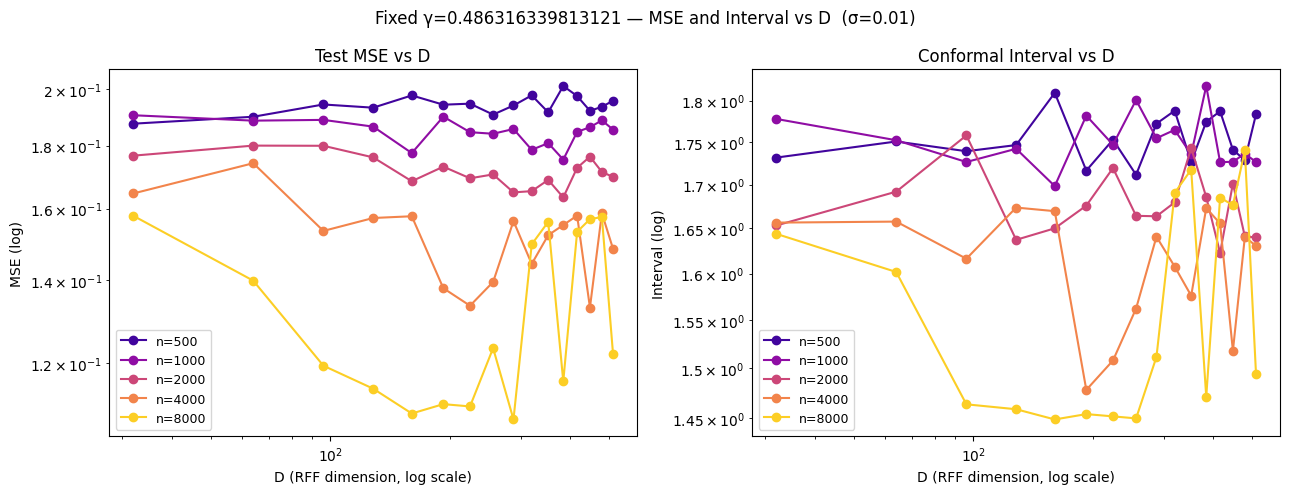

Fixed Gamma σ=0.01 — Near-best D:
   n  best_mse  baseline_mse_D32  raw_near_best_D  recommended_D_monotone
 200  0.197939          0.207171               96                      96
 500  0.187483          0.187483               32                      96
1000  0.175343          0.190456              384                     384
2000  0.163399          0.176633              384                     384
4000  0.133077          0.164615              224                     384
6000  0.105436          0.166437              288                     384
8000  0.108008          0.157896              160                     384


In [64]:
plot_ns = [n for n in _N_GRID if n not in [200, 6000]]
palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(plot_ns)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, n in enumerate(plot_ns):
    sub = D_df_fg_01[D_df_fg_01['n'] == n]
    axes[0].plot(sub['D'], sub['test_mse'], marker='o', color=palette[i], label=f'n={n}')
    axes[1].plot(sub['D'], sub['interval'], marker='o', color=palette[i], label=f'n={n}')
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('D (RFF dimension, log scale)'); ax.legend(fontsize=9)
axes[0].set_title('Test MSE vs D'); axes[0].set_ylabel('MSE (log)')
axes[1].set_title('Conformal Interval vs D'); axes[1].set_ylabel('Interval (log)')
plt.suptitle(f'Fixed γ={GAMMA_DEF} — MSE and Interval vs D  (σ=0.01)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec3b_fixed_gamma_nD_plot_sigma001.png'), dpi=120, bbox_inches='tight')
plt.show()

summary_rows_fg_01 = []; raw_Ds_fg_01 = []
for n, row in mse_pivot_fg_01.iterrows():
    row = row.sort_index(); best_mse = row.min(); base_mse = row.loc[32]
    thresh = best_mse + 0.05 * (base_mse - best_mse)
    near_best_D = row[row <= thresh].index.min()
    raw_Ds_fg_01.append(int(near_best_D))
    summary_rows_fg_01.append({'n': int(n), 'best_mse': float(best_mse),
                               'baseline_mse_D32': float(base_mse), 'raw_near_best_D': int(near_best_D)})
summary_df_fg_01 = pd.DataFrame(summary_rows_fg_01).sort_values('n')
summary_df_fg_01['recommended_D_monotone'] = np.maximum.accumulate(summary_df_fg_01['raw_near_best_D'].values)
print('Fixed Gamma σ=0.01 — Near-best D:')
print(summary_df_fg_01.to_string(index=False))

In [65]:
# ── Fixed Gamma: Joint (n, D) grid  σ=0.1 ───────────────────────────────────
_D_grid_fg_1 = list(range(32, 513, 32))
nD_rows_fg_1 = []
for n in tqdm(_N_GRID, desc='n loop fixed-γ σ=0.1'):
    rng_n = np.random.RandomState(n)
    X_n = rng_n.uniform(-6, 6, (n, 2)).astype('float32')
    y_n = f_star(X_n) + (0.1 * rng_n.randn(n)).astype('float32')
    for D in _D_grid_fg_1:
        set_seed(SEED)
        net = KernelNet(D=D, gamma=GAMMA_DEF); net.apply(init_weights)
        net, opt, trl, tel = train_model(net, X_n, y_n, X_te_sh1, y_te_sh1, verbose=False)
        cov, lng, _ = conformal_split(net, X_cal_sh1, y_cal_sh1, X_te_sh1, y_te_sh1)
        nD_rows_fg_1.append({'n': n, 'D': D, 'test_mse': tel[-1], 'interval': lng})
        print(f'  n={n:5d}  D={D:4d}: test={tel[-1]:.5f}  interval={lng:.4f}')

D_df_fg_1 = pd.DataFrame(nD_rows_fg_1)
mse_pivot_fg_1 = D_df_fg_1.pivot(index='n', columns='D', values='test_mse')
int_pivot_fg_1 = D_df_fg_1.pivot(index='n', columns='D', values='interval')
D_df_fg_1.to_csv(os.path.join(RESULTS_DIR, 'sec3b_fixed_gamma_nD_sigma01.csv'), index=False)
print(mse_pivot_fg_1.round(5).to_string())

n loop fixed-γ σ=0.1:   0%|          | 0/7 [00:00<?, ?it/s]

  n=  200  D=  32: test=0.22096  interval=2.0186
  n=  200  D=  64: test=0.21304  interval=1.9669
  n=  200  D=  96: test=0.20835  interval=1.8987
  n=  200  D= 128: test=0.21185  interval=1.9286
  n=  200  D= 160: test=0.21429  interval=1.9395
  n=  200  D= 192: test=0.22703  interval=1.9387
  n=  200  D= 224: test=0.22059  interval=1.9612
  n=  200  D= 256: test=0.22759  interval=2.0245
  n=  200  D= 288: test=0.21955  interval=1.9818
  n=  200  D= 320: test=0.22693  interval=2.0619
  n=  200  D= 352: test=0.22828  interval=2.0965
  n=  200  D= 384: test=0.22490  interval=2.0703
  n=  200  D= 416: test=0.21981  interval=1.9847
  n=  200  D= 448: test=0.22358  interval=2.0262
  n=  200  D= 480: test=0.22237  interval=2.1012


n loop fixed-γ σ=0.1:  14%|█▍        | 1/7 [03:22<20:16, 202.78s/it]

  n=  200  D= 512: test=0.22426  interval=2.0712
  n=  500  D=  32: test=0.19917  interval=1.7955
  n=  500  D=  64: test=0.19983  interval=1.8096
  n=  500  D=  96: test=0.20541  interval=1.8093
  n=  500  D= 128: test=0.20254  interval=1.7810
  n=  500  D= 160: test=0.20726  interval=1.8920
  n=  500  D= 192: test=0.20527  interval=1.8138
  n=  500  D= 224: test=0.20313  interval=1.7901
  n=  500  D= 256: test=0.20305  interval=1.8359
  n=  500  D= 288: test=0.20700  interval=1.8454
  n=  500  D= 320: test=0.20847  interval=1.8688
  n=  500  D= 352: test=0.20266  interval=1.8202
  n=  500  D= 384: test=0.21255  interval=1.8912
  n=  500  D= 416: test=0.20791  interval=1.8550
  n=  500  D= 448: test=0.20487  interval=1.8860
  n=  500  D= 480: test=0.20346  interval=1.8076


n loop fixed-γ σ=0.1:  29%|██▊       | 2/7 [09:56<26:15, 315.15s/it]

...

  n= 4000  D= 512: test=0.15459  interval=1.6987
  n= 6000  D=  32: test=0.17256  interval=1.7634
  n= 6000  D=  64: test=0.13129  interval=1.5409
  n= 6000  D=  96: test=0.13650  interval=1.6356
  n= 6000  D= 128: test=0.16058  interval=1.7031
  n= 6000  D= 160: test=0.14020  interval=1.7023
  n= 6000  D= 192: test=0.12060  interval=1.4821
  n= 6000  D= 224: test=0.12545  interval=1.4834
  n= 6000  D= 256: test=0.12834  interval=1.5030
  n= 6000  D= 288: test=0.11494  interval=1.4904
  n= 6000  D= 320: test=0.15735  interval=1.6982
  n= 6000  D= 352: test=0.16498  interval=1.7405
  n= 6000  D= 384: test=0.16380  interval=1.7567
  n= 6000  D= 416: test=0.16433  interval=1.7088
  n= 6000  D= 448: test=0.16255  interval=1.7257
  n= 6000  D= 480: test=0.16699  interval=1.7270


n loop fixed-γ σ=0.1:  86%|████████▌ | 6/7 [6:59:43<2:11:34, 7894.97s/it]

  n= 6000  D= 512: test=0.13853  interval=1.6934
  n= 8000  D=  32: test=0.16045  interval=1.6568
  n= 8000  D=  64: test=0.15057  interval=1.6497
  n= 8000  D=  96: test=0.13014  interval=1.4915
  n= 8000  D= 128: test=0.12032  interval=1.5131
  n= 8000  D= 160: test=0.11779  interval=1.5003
  n= 8000  D= 192: test=0.15576  interval=1.7008
  n= 8000  D= 224: test=0.11813  interval=1.4950
  n= 8000  D= 256: test=0.13020  interval=1.5062
  n= 8000  D= 288: test=0.15866  interval=1.7321
  n= 8000  D= 320: test=0.14101  interval=1.6822
  n= 8000  D= 352: test=0.15236  interval=1.6628
  n= 8000  D= 384: test=0.13671  interval=1.5475
  n= 8000  D= 416: test=0.16063  interval=1.7513
  n= 8000  D= 448: test=0.16480  interval=1.7331
  n= 8000  D= 480: test=0.16458  interval=1.7773


n loop fixed-γ σ=0.1: 100%|██████████| 7/7 [7:33:52<00:00, 3890.39s/it]  

  n= 8000  D= 512: test=0.12918  interval=1.5343
D         32       64       96       128      160      192      224      256      288      320      352      384      416      448      480      512
n                                                                                                                                                   
200   0.22096  0.21304  0.20835  0.21185  0.21429  0.22703  0.22059  0.22759  0.21955  0.22693  0.22828  0.22490  0.21981  0.22358  0.22237  0.22426
500   0.19917  0.19983  0.20541  0.20254  0.20726  0.20527  0.20313  0.20305  0.20700  0.20847  0.20266  0.21255  0.20791  0.20487  0.20346  0.20847
1000  0.19738  0.19502  0.19528  0.19305  0.18542  0.19325  0.19235  0.19179  0.19486  0.18543  0.18787  0.18215  0.19097  0.19398  0.19525  0.19316
2000  0.18350  0.18662  0.18738  0.18346  0.17884  0.18198  0.17481  0.17813  0.18015  0.17639  0.17671  0.17401  0.17534  0.18022  0.17913  0.17063
4000  0.17165  0.17793  0.15747  0.15474  0.16403  0.1663

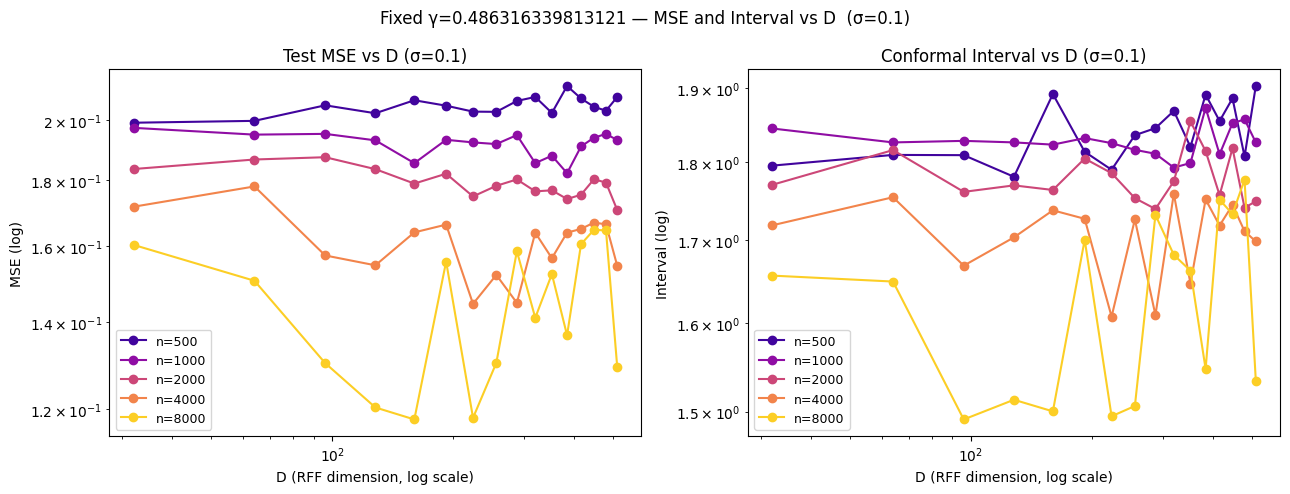

Fixed Gamma σ=0.1 — Near-best D:
   n  best_mse  baseline_mse_D32  raw_near_best_D  recommended_D_monotone
 200  0.208346          0.220956               96                      96
 500  0.199172          0.199172               32                      96
1000  0.182153          0.197375              384                     384
2000  0.170634          0.183497              512                     512
4000  0.144537          0.171649              224                     512
6000  0.114936          0.172564              288                     512
8000  0.117792          0.160448              160                     512


In [66]:
plot_ns = [n for n in _N_GRID if n not in [200, 6000]]
palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(plot_ns)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, n in enumerate(plot_ns):
    sub = D_df_fg_1[D_df_fg_1['n'] == n]
    axes[0].plot(sub['D'], sub['test_mse'], marker='o', color=palette[i], label=f'n={n}')
    axes[1].plot(sub['D'], sub['interval'], marker='o', color=palette[i], label=f'n={n}')
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('D (RFF dimension, log scale)'); ax.legend(fontsize=9)
axes[0].set_title('Test MSE vs D (σ=0.1)'); axes[0].set_ylabel('MSE (log)')
axes[1].set_title('Conformal Interval vs D (σ=0.1)'); axes[1].set_ylabel('Interval (log)')
plt.suptitle(f'Fixed γ={GAMMA_DEF} — MSE and Interval vs D  (σ=0.1)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec3b_fixed_gamma_nD_plot_sigma01.png'), dpi=120, bbox_inches='tight')
plt.show()

summary_rows_fg_1 = []; raw_Ds_fg_1 = []
for n, row in mse_pivot_fg_1.iterrows():
    row = row.sort_index(); best_mse = row.min(); base_mse = row.loc[32]
    thresh = best_mse + 0.05 * (base_mse - best_mse)
    near_best_D = row[row <= thresh].index.min()
    raw_Ds_fg_1.append(int(near_best_D))
    summary_rows_fg_1.append({'n': int(n), 'best_mse': float(best_mse),
                              'baseline_mse_D32': float(base_mse), 'raw_near_best_D': int(near_best_D)})
summary_df_fg_1 = pd.DataFrame(summary_rows_fg_1).sort_values('n')
summary_df_fg_1['recommended_D_monotone'] = np.maximum.accumulate(summary_df_fg_1['raw_near_best_D'].values)
print('Fixed Gamma σ=0.1 — Near-best D:')
print(summary_df_fg_1.to_string(index=False))

## Section 4: γ Sensitivity Analysis

$\gamma$ is the RFF bandwidth. We sweep $\gamma \in \{0.1, 0.5, 1.0, 2.0, 5.0\}$
using the best $D$ from Section 3. Also shows where the median-distance heuristic
$\gamma_\text{median} = 1/\sqrt{\text{median\_sqdist}}$ falls in the sweep.

In [67]:
dists = np.sum((X_tr[None, :, :] - X_tr[:, None, :])**2, axis=-1)
dists_flat = dists[np.triu_indices(len(X_tr), k=1)]
median_sqdist = float(np.median(dists_flat))
gamma_median  = float(1.0 / np.sqrt(median_sqdist))
print(f'median_sqdist = {median_sqdist:.4f}')
print(f'gamma_median  = {gamma_median:.6f}  (= 1/sqrt(median_sqdist))')
print(f'Using D_best: MLKM={best_D_mlkm}  ResKernelNet={best_D_rkm}')

median_sqdist = 4.2283
gamma_median  = 0.486316  (= 1/sqrt(median_sqdist))
Using D_best: MLKM=32  ResKernelNet=224


gamma sweep: 100%|██████████| 5/5 [27:40<00:00, 332.03s/it]


 gamma  MLKM_train  MLKM_test  MLKM_interval  ResKernelNet_train  ResKernelNet_test  ResKernelNet_interval
   0.1      0.1335     0.1329         1.2349              0.1341             0.1347                 1.2623
   0.5      0.0402     0.0412         0.8360              0.0345             0.0344                 0.7159
   1.0      0.0163     0.0152         0.5023              0.0125             0.0124                 0.4554
   2.0      0.0047     0.0053         0.3000              0.0018             0.0020                 0.1840
   5.0      0.0083     0.0090         0.4226              0.0003             0.0004                 0.0789


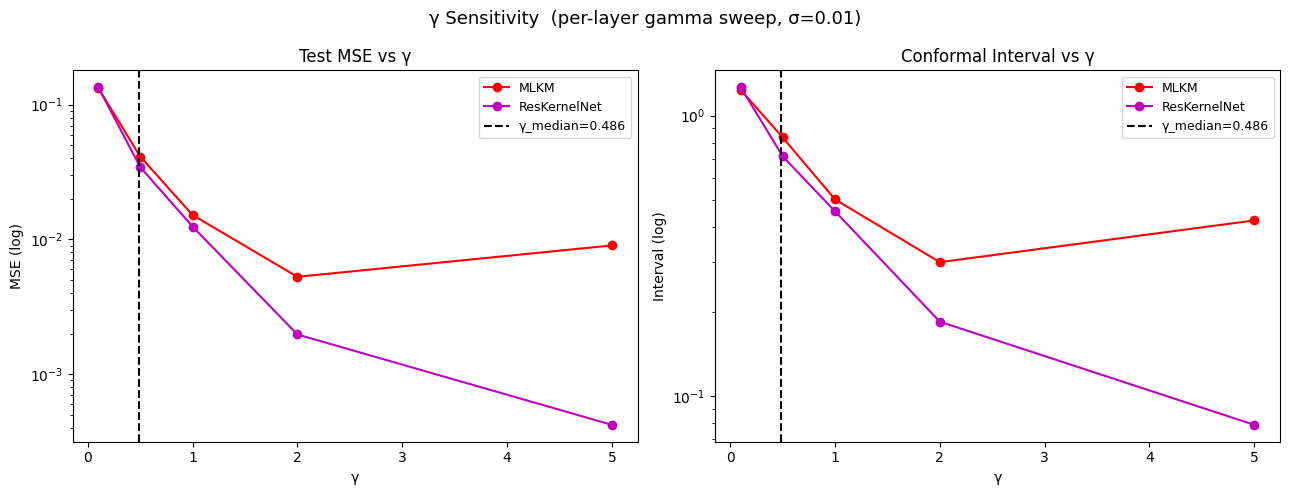

Saved → ex3_results/sec4_gamma_sensitivity.png


In [68]:
gamma_results = []
for gamma in tqdm(GAMMAS, desc='gamma sweep'):
    row = {'gamma': gamma}
    for label, make_net in [
        ('MLKM',         lambda g=gamma: KernelNet(D=best_D_mlkm, gamma=g)),
        ('ResKernelNet', lambda g=gamma: ResKernelNet(D1=best_D_rkm, gamma=g)),
    ]:
        set_seed(SEED)
        net = make_net(); net.apply(init_weights)
        net, opt, trl, tel = train_model(net, X_tr, y_tr, X_te, y_te, verbose=False)
        cov, lng, q = conformal_split(net, X_cal, y_cal, X_te, y_te)
        row[f'{label}_train']    = trl[-1]
        row[f'{label}_test']     = tel[-1]
        row[f'{label}_interval'] = lng
    gamma_results.append(row)

gamma_df = pd.DataFrame(gamma_results)
print(gamma_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, c in [('MLKM','r'), ('ResKernelNet','m')]:
    axes[0].plot(gamma_df['gamma'], gamma_df[f'{label}_test'],     marker='o', ls='-', color=c, label=label)
    axes[1].plot(gamma_df['gamma'], gamma_df[f'{label}_interval'], marker='o', ls='-', color=c, label=label)
for ax in axes:
    ax.axvline(gamma_median, color='k', ls='--', lw=1.5, label=f'γ_median={gamma_median:.3f}')
    ax.set_xlabel('γ'); ax.set_yscale('log'); ax.legend(fontsize=9)
axes[0].set_title('Test MSE vs γ'); axes[0].set_ylabel('MSE (log)')
axes[1].set_title('Conformal Interval vs γ'); axes[1].set_ylabel('Interval (log)')
plt.suptitle('γ Sensitivity  (per-layer gamma sweep, σ=0.01)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sec4_gamma_sensitivity.png'), dpi=120, bbox_inches='tight')
plt.show()
gamma_df.to_csv(os.path.join(RESULTS_DIR, 'sec4_gamma_sensitivity_results.csv'), index=False)
print(f'Saved → {RESULTS_DIR}/sec4_gamma_sensitivity.png')

## Final Summary

| Analysis | Key Finding |
|---|---|
| True function | Multi-scale: slow envelope × fast oscillation — single-kernel GPs struggle |
| Baseline (σ=0.01) | Expected: MLKM/ResKernelNet competitive with or better than DGP |
| Baseline (σ=0.1) | Same ordering under higher noise |
| Sample size (σ=0.01) | MLKM advantage over DGP grows with n (multi-scale structure revealed) |
| Sample size (σ=0.1) | Same pattern under higher noise |

**Saved outputs (in `ex3_results/`):**

| File | Content |
|---|---|
| `ex3_true_function.png` | 3D + contour of $f^*$ |
| `sec1_training_curves_sigma001.png` | Training curves σ=0.01 |
| `sec1_training_curves_sigma01.png` | Training curves σ=0.1 |
| `sec1_prediction_surfaces_sigma001.png` | 3×3 surface grid σ=0.01 |
| `sec1_prediction_surfaces_sigma01.png` | 3×3 surface grid σ=0.1 |
| `sec1_baseline_sigma001.csv` | MSE/time table σ=0.01 |
| `sec1_baseline_sigma01.csv` | MSE/time table σ=0.1 |
| `sec1_conformal_sigma001.csv` | Conformal results σ=0.01 |
| `sec1_conformal_sigma01.csv` | Conformal results σ=0.1 |
| `sec2_sigma001_sample_size.png` | Section 2 3-panel plot σ=0.01 |
| `sec2_sigma01_sample_size.png` | Section 2 3-panel plot σ=0.1 |
| `sec2_sigma001_conformal_interval_vs_n.png` | Conformal interval vs n σ=0.01 |
| `sec2_sigma01_conformal_interval_vs_n.png` | Conformal interval vs n σ=0.1 |

**Why the multi-scale function challenges DGP specifically:**
1. DGP's RBF kernel has one length-scale parameter per layer. To fit the fast oscillation (period ~1.6), it needs a small length-scale. But a small length-scale ignores the global envelope variation (period ~12). A single-layer GP must choose one or the other.
2. MLKM Layer 1 (wider kernel, smaller γ) captures the global envelope; Layer 2 (tighter kernel, larger γ) resolves the fast oscillation — exactly the coarse-to-fine hierarchy that the architecture was designed for.
3. Both the theoretical motivation and the empirical gap widen with n: more data makes the multi-scale structure more apparent, and DGP's misspecification more costly.